# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Etapa 1: Obtenção, Mapeamento, Diagnóstico e Ingestão da API

Este notebook é responsável por:
1. Configurar o ambiente e importar bibliotecas de manipulação, visualização e auditoria de dados (`pandas`, `missingno`, `seaborn`, `itables`).
2. Definir os caminhos do projeto de forma reprodutível.
3. Documentar o Dicionário de Dados oficial e as regras de negócio de domínio do Cartola FC.
4. Definir as listas semânticas de colunas para direcionar a Análise Exploratória (EDA).
5. Carregar a base histórica de atletas (`base_case_gm.csv`) preservando seu estado bruto (**Opção B**).
6. Executar o diagnóstico de qualidade de dados (tipagem, nulos, valores únicos/frequências, duplicidades e matriz `missingno`), renderizados com tabelas dinâmicas interativas (`itables`).
7. Realizar a análise de negócio de escalação: correlação entre `status_pre`, taxa de participação real em campo e pontuação esperada.
8. Documentar a síntese do diagnóstico exploratório, anomalias encontradas.
9. Desenvolver a jornada didática de consumo da API de apoio: demonstração prática dos erros `401`, `paginação`, `429` e `503`, culminando no **Cliente HTTP Resiliente (Versão 5)** com teste de amostragem e extração completa.

> ⚠️ **Atenção:** se os outputs não aparecerem corretamente, **execute novamente a Célula 1** para recarregar o `itables` e restaurar a visualização.

### 1. Importação das Bibliotecas e Configurações

In [1]:
from pathlib import Path
import json
import time
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import requests
import itables
from itables import init_notebook_mode, show
import requests

# Adiciona o diretório raiz ao sys.path para importar módulos de src
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Renderização inline do matplotlib
%matplotlib inline

# Configurações estéticas e de formatação
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Ativa tabelas interativas (com busca em tempo real, ordenação por coluna e paginação)
init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50, 100]

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Itables version: {itables.__version__}")

Pandas version: 3.0.5
Numpy version: 2.5.2
Itables version: 2.9.1


### 2. Definição dos Caminhos do Projeto

In [2]:
# Definição da raiz do projeto e pastas de dados
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CSV_PATH = DATA_RAW_DIR / "base_case_gm.csv"

print(f"Diretório Raiz: {PROJECT_ROOT}")
print(f"Arquivo CSV: {CSV_PATH} (Existe: {CSV_PATH.exists()})")

Diretório Raiz: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual
Arquivo CSV: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/data/raw/base_case_gm.csv (Existe: True)


### 3. Dicionário de Dados e Regras de Negócio

A granularidade da base é de **um registro por atleta e partida disputada**, cobrindo as temporadas de **2022 a 2025**.

> *Nota de Domínio*: Uma rodada normalmente reúne dez partidas, mas jogos podem ser remarcados para a rodada seguinte. Nesses casos, uma rodada concentra mais de dez partidas e um atleta pode figurar em mais de um registro dentro dela.

---

#### 3.1 Mapeamento por Domínio de Negócio

| Domínio | Colunas no CSV | Descrição | Tipo Esperado |
| :--- | :--- | :--- | :--- |
| **Identificação** | `atleta_id`, `apelido`, `ano`, `rodada_id`, `clube_id`, `posicao_id` | Chaves primárias, temporada, clube e função do atleta | Inteiros / Texto |
| **Situação do Atleta** | `status_pre`, `status_inicial`, `entrou_em_campo`, `minutos_jogados` | Status divulgado pré-rodada, escalação e tempo de jogo | Categórico / Booleano / Numérico |
| **Mercado (Cartola)** | `preco_num`, `variacao_num`, `media_num`, `jogos_num` | Variáveis financeiras e histórico acumulado | Float / Inteiro |
| **Desempenho (Target)** | `pontos_num` | Pontuação final obtida na rodada | Float |
| **Contexto do Confronto** | `home_dummy`, `opponent`, `match_id` | Mando de campo, adversário e chave de junção com a API | Binário (0/1) / Inteiro |
| **Scouts Positivos** | `G`, `A`, `SG`, `FF`, `FT`, `FD`, `DD`, `DP`, `DE`, `DS`, `FS`, `PS` | Contagens de ações ofensivas e defensivas positivas na rodada | Float/Int |
| **Scouts Negativos** | `GS`, `GC`, `CA`, `CV`, `FC`, `I`, `PP`, `PC` | Contagens de faltas, cartões, gols sofridos/contra e pênaltis | Float/Int |

---

#### 3.2 Detalhamento dos Campos e Domínios

##### Identificação
| Campo | Tipo | Descrição | Domínio |
| :--- | :--- | :--- | :--- |
| `atleta_id` | inteiro | Identificador do atleta | - |
| `apelido` | texto | Nome pelo qual o atleta é conhecido | - |
| `ano` | inteiro | Temporada | 2022 a 2025 |
| `rodada_id` | inteiro | Rodada do campeonato | 1 a 38 |
| `clube_id` | inteiro | Identificador do clube do atleta na rodada | consultável na API |
| `posicao_id` | inteiro | Posição do atleta | 1 a 6 |

##### Situação do Atleta
| Campo | Tipo | Descrição | Domínio |
| :--- | :--- | :--- | :--- |
| `status_pre` | texto | Situação divulgada antes da rodada | Provável, Dúvida, Nulo, Suspenso, Contundido |
| `status_inicial` | texto | Condição na escalação | titulares ou reservas |
| `entrou_em_campo` | booleano | Indicador de participação na partida | True / False |
| `minutos_jogados` | numérico | Minutos em campo na rodada | 0 a 90+ minutos de acréscimo |

##### Mercado
| Campo | Tipo | Descrição | Domínio |
| :--- | :--- | :--- | :--- |
| `preco_num` | numérico | Preço do atleta em cartoletas na rodada | sempre positivo |
| `variacao_num` | numérico | Variação do preço em relação à rodada anterior | pode ser negativa |
| `media_num` | numérico | Média de pontos do atleta na temporada, acumulada até a rodada | real |
| `jogos_num` | inteiro | Jogos disputados na temporada, acumulados até a rodada | $\ge 0$ |

##### Desempenho
| Campo | Tipo | Descrição | Domínio |
| :--- | :--- | :--- | :--- |
| `pontos_num` | numérico | Pontuação do atleta na rodada | pode ser negativa |

##### Contexto da Partida
| Campo | Tipo | Descrição | Domínio |
| :--- | :--- | :--- | :--- |
| `home_dummy` | inteiro | 1 quando o clube do atleta é mandante, 0 quando visitante | 0 ou 1 |
| `opponent` | inteiro | Identificador do clube adversário | consultável na API |
| `match_id` | inteiro | Identificador da partida - chave de ligação com a API | ID do jogo |

---

#### 3.3 Scouts da Rodada

##### Ações Positivas
| Campo | Descrição | Aplicação |
| :--- | :--- | :--- |
| `G` | Gol | Todas as posições |
| `A` | Assistência | Todas as posições |
| `SG` | Jogo sem sofrer gol | Goleiros e Defensores (Lateral/Zagueiro) |
| `FF` | Finalização para fora | Todas as posições |
| `FT` | Finalização na trave | Todas as posições |
| `FD` | Finalização defendida | Todas as posições |
| `DD` | Defesa difícil | Apenas Goleiros |
| `DP` | Defesa de pênalti | Apenas Goleiros |
| `DE` | Defesa (registro auxiliar de goleiro) | Apenas Goleiros |
| `DS` | Desarme | Todas as posições |
| `FS` | Falta sofrida | Todas as posições |
| `PS` | Pênalti sofrido | Todas as posições |

##### Ações Negativas
| Campo | Descrição | Aplicação |
| :--- | :--- | :--- |
| `GS` | Gol sofrido | Apenas Goleiros |
| `GC` | Gol contra | Todas as posições |
| `CA` | Cartão amarelo | Todas as posições |
| `CV` | Cartão vermelho | Todas as posições |
| `FC` | Falta cometida | Todas as posições |
| `I` | Impedimento | Todas as posições |
| `PP` | Pênalti perdido | Todas as posições |
| `PC` | Pênalti cometido | Todas as posições |

---

#### 3.4 Tabela de Posições

| `posicao_id` | Posição | Sigla | Scouts Específicos |
| :--- | :--- | :--- | :--- |
| **1** | Goleiro | gol | `DD`, `DP`, `DE`, `GS`, `SG` |
| **2** | Lateral | lat | `SG` |
| **3** | Zagueiro | zag | `SG` |
| **4** | Meia | mei | - |
| **5** | Atacante | ata | - |
| **6** | Técnico | tec | - |

---

#### 3.5 Observações e Regras Críticas de Domínio
- **Escopo dos Scouts**: Contagens exclusivas da própria rodada (não acumulados da temporada).
- **Campos Acumulados**: `media_num` e `jogos_num` são acumulados até a rodada atual pelo Cartola.
- **Variação de Preço**: `variacao_num` reflete a oscilação de patrimônio em decorrência da performance na rodada.
- **Especificidade de Scouts por Posição**: `DD`, `DP`, `DE` e `GS` aplicam-se apenas a goleiros (`posicao_id = 1`); `SG` aplica-se apenas a goleiros e defensores (`posicao_id in [1, 2, 3]`).

### 4. Definição das Listas Semânticas de Colunas

In [3]:
# Agrupamentos de colunas por domínio semântico
COLS_ID = ["atleta_id", "apelido", "ano", "rodada_id", "clube_id", "posicao_id"]
COLS_SITUACAO = ["status_pre", "status_inicial", "entrou_em_campo", "minutos_jogados"]
COLS_MERCADO = ["preco_num", "variacao_num", "media_num", "jogos_num"]
COLS_TARGET = ["pontos_num"]
COLS_CONTEXTO = ["home_dummy", "opponent", "match_id"]
COLS_SCOUTS_POS = ["G", "A", "SG", "FF", "FT", "FD", "DD", "DP", "DE", "DS", "FS", "PS"]
COLS_SCOUTS_NEG = ["GS", "GC", "CA", "CV", "FC", "I", "PP", "PC"]
COLS_SCOUTS = COLS_SCOUTS_POS + COLS_SCOUTS_NEG

ALL_EXPECTED_COLS = COLS_ID + COLS_SITUACAO + COLS_MERCADO + COLS_TARGET + COLS_CONTEXTO + COLS_SCOUTS
print(f"Total de colunas mapeadas no dicionário: {len(ALL_EXPECTED_COLS)}")

Total de colunas mapeadas no dicionário: 38


### 5. Carga Inicial do Dataset Histórico (`base_case_gm.csv`) - Opção B (Dados Brutos)

In [4]:
# Carga sem coerção forçada de tipos, preservando o estado bruto para mapeamento de inconsistências
df_raw = pd.read_csv(CSV_PATH)

print(f"Dimensões do dataset: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
df_raw.head(5)

Dimensões do dataset: 117,469 linhas x 38 colunas


atleta_id             apelido   ano  rodada_id  clube_id  posicao_id  \
0      11633     Kaique Oliveira  2024         20       127           4   
1      11798     Geraldo Antunes  2025         13       110           6   
2      10470       Pedro Peixoto  2024         14       127           3   
3      10661      Adriel Barbosa  2025         36       115           4   
4      10218  Norberto Guimarães  2022         30       118           5   

  status_pre status_inicial preco_num  variacao_num  media_num  jogos_num  \
0       Nulo        reserva      1.98          0.00      -0.25          4   
1   PROVÁVEL              0      9.39          0.36       6.50         13   
2       Nulo        titular       2.8         -1.02       2.12         10   
3       Nulo        reserva      1.87          0.00       0.28         14   
4       Nulo        reserva      5.55          1.34       2.24         21   

   pontos_num  minutos_jogados  entrou_em_campo  home_dummy  opponent  \
0        0.00             0.00            False        1.00    120.00   
1        4.95           102.00             True        0.00    103.00   
2       -1.60            89.00             True        1.00    102.00   
3        0.00             0.00            False        1.00    104.00   
4        7.60            39.00             True        0.00    124.00   

   match_id    G    A   SG   FF   FT   FD  DD   DP   DE   DS   FS   PS   GS  \
0    900849 0.00 0.00 0.00 0.00 0.00 0.00 NaN 0.00 0.00 0.00 0.00 0.00 0.00   
1    901223 0.00 0.00 0.00 0.00 0.00 0.00 NaN 0.00 0.00 0.00 0.00 0.00 0.00   
2    901049 0.00 0.00 0.00 0.00 0.00 0.00 NaN 0.00 0.00 0.00 0.00 0.00 0.00   
3    901290 0.00 0.00 0.00 0.00 0.00 0.00 NaN 0.00 0.00 0.00 0.00 0.00 0.00   
4    900097 1.00 0.00 0.00 0.00 0.00 0.00 NaN 0.00 0.00 0.00 0.00 0.00 0.00   

    GC   CA   CV   FC    I   PP   PC  
0 0.00 0.00 0.00 0.00 0.00 0.00 0.00  
1 0.00 0.00 0.00 0.00 0.00 0.00 0.00  
2 0.00 1.00 0.00 2.00 0.00 0.00 0.00  
3 0.00 0.00 0.00 0.00 0.00 0.00 0.00  
4 0.00 0.00 0.00 1.00 0.00 0.00 0.00

### 6. Diagnóstico Exploratório e Qualidade dos Dados

In [5]:
def resumo_qualidade_dados(
    df: pd.DataFrame,
    colunas: list[str] | None = None,
    top_n: int = 4
) -> pd.DataFrame:
    """
    Executa uma auditoria detalhada de qualidade e integridade dos dados para um conjunto de variáveis.

    Esta função consolida metadados estruturais essenciais para responder à Questão 1 do desafio técnico
    ("Que inconsistências você encontrou na base?"), avaliando completude, tipagem inferida,
    cardinalidade de valores distintos e a distribuição percentual dos valores mais frequentes.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo a base de dados a ser auditada.
    colunas : list[str] | None, default=None
        Lista com os nomes das colunas a serem analisadas (ou grupos semânticos como COLS_ID, COLS_SCOUTS).
        Se None, todas as colunas presentes em `df` serão avaliadas.
    top_n : int, default=4
        Quantidade dos valores mais frequentes (incluindo NaN) a serem detalhados com sua respectiva proporção.

    Retorno:
    --------
    pd.DataFrame
        Tabela estruturada contendo:
        - coluna: Nome da variável.
        - tipo_dado: Tipo primitivo inferido pelo pandas (ex: int64, float64, object, bool).
        - total_linhas: Volume total de registros no dataset.
        - qtd_nulos: Quantidade absoluta de valores ausentes (NaN/None).
        - pct_nulos (%): Percentual relativo de ausências em relação ao total de linhas.
        - qtd_unicos: Cardinalidade de valores únicos não nulos (nunique).
        - pct_unicos (%): Proporção de valores distintos em relação às linhas válidas.
        - top_{top_n}_valores_frequentes: String descritiva com os N valores mais recorrentes e suas proporções.
    """
    cols = colunas if colunas is not None else df.columns.tolist()
    total_linhas = len(df)
    registros = []

    for col in cols:
        serie = df[col]
        n_nulos = int(serie.isna().sum())
        pct_nulos = (n_nulos / total_linhas) * 100
        n_validos = total_linhas - n_nulos
        n_unicos = int(serie.nunique(dropna=True))
        pct_unicos = (n_unicos / n_validos * 100) if n_validos > 0 else 0.0
        
        # Top N valores frequentes com proporção formatada
        top_vals_series = serie.value_counts(normalize=True, dropna=False).head(top_n)
        top_vals_str = ", ".join([
            f"{f'NaN' if pd.isna(val) else val} ({pct * 100:.1f}%)"
            for val, pct in top_vals_series.items()
        ])
        
        registros.append({
            "coluna": col,
            "tipo_dado": str(serie.dtype),
            "total_linhas": total_linhas,
            "qtd_nulos": n_nulos,
            "pct_nulos (%)": pct_nulos,
            "qtd_unicos": n_unicos,
            "pct_unicos (%)": pct_unicos,
            f"top_{top_n}_valores_frequentes": top_vals_str
        })
        
    df_resumo = pd.DataFrame(registros)
    return df_resumo


def analisar_duplicidades(
    df: pd.DataFrame,
    chaves_negocio: list[list[str]] | None = None
) -> dict:
    """
    Audita duplicidades estritas de linhas completas e avalia a unicidade de chaves primárias e de domínio.

    No contexto do Cartola FC, esta análise é fundamental para identificar:
    1. Registros 100% redundantes gerados por erros de ingestão.
    2. Partidas remarcadas (onde um mesmo atleta pode atuar mais de uma vez em uma mesma rodada do calendário).
    3. Violações de integridade relacional entre atleta e partida (`match_id`).

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo a base histórica a ser inspecionada.
    chaves_negocio : list[list[str]] | None, default=None
        Lista de combinações de colunas que representam chaves lógicas de negócio.
        Por padrão, avalia:
        - ['atleta_id', 'ano', 'rodada_id'] (atleta por rodada do campeonato)
        - ['atleta_id', 'match_id'] (atleta por partida individual)
        - ['match_id', 'ano', 'rodada_id'] (partida por rodada)

    Retorno:
    --------
    dict
        Dicionário estruturado com volumetria e percentuais de duplicidade por chave avaliada.
    """
    if chaves_negocio is None:
        chaves_negocio = [
            ["atleta_id", "ano", "rodada_id"],           # Chave de rodada do atleta
            ["atleta_id", "match_id"],                  # Chave de partida do atleta
            ["match_id", "ano", "rodada_id"]            # Chave de partida na rodada
        ]
        
    dups_linhas_completas = int(df.duplicated().sum())
    resultado = {
        "total_linhas": len(df),
        "linhas_100pct_duplicadas": dups_linhas_completas,
        "duplicidades_por_chave": {}
    }
    
    for chave in chaves_negocio:
        if all(c in df.columns for c in chave):
            qtd_dups = int(df.duplicated(subset=chave, keep=False).sum())
            chave_nome = " + ".join(chave)
            resultado["duplicidades_por_chave"][chave_nome] = {
                "linhas_afetadas": qtd_dups,
                "pct_afetadas (%)": (qtd_dups / len(df)) * 100
            }
            
    return resultado


def plotar_diagnostico_nulos(
    df: pd.DataFrame,
    colunas: list[str] | None = None,
    figsize_matrix: tuple = (14, 5)
):
    """
    Gera diagnósticos visuais de dados faltantes: gráfico de barras quantitativo e matriz espectral (`missingno`).

    Visualizações geradas:
    1. Gráfico de Barras Horizontais: Quantifica o percentual exato de valores nulos para cada coluna com ausência.
    2. Matriz Espectral (missingno.matrix): Mapeia a localização espacial dos nulos ao longo do índice do dataset,
       permitindo identificar se os dados ausentes ocorrem de forma contígua (ex: bloco de anos específicos) ou aleatória.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo os dados a serem visualizados.
    colunas : list[str] | None, default=None
        Subconjunto opcional de colunas a serem plotadas. Se None, utiliza todas as colunas do dataset.
    figsize_matrix : tuple, default=(14, 5)
        Dimensões da figura para a matriz do missingno (largura, altura em polegadas).

    Retorno:
    --------
    None (renderiza as figuras diretamente no output do notebook).
    """
    cols = colunas if colunas is not None else df.columns.tolist()
    df_subset = df[cols]
    
    # 1. Gráfico de Barras com % de Nulos
    pct_nulos = df_subset.isna().mean() * 100
    cols_com_nulos = pct_nulos[pct_nulos > 0].sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(cols_com_nulos) * 0.35)))
    if len(cols_com_nulos) > 0:
        cols_com_nulos.plot(kind="barh", ax=ax, color="#d9534f", edgecolor="black", alpha=0.85)
        ax.set_title("Percentual de Valores Nulos por Coluna (%)", fontsize=13, pad=12)
        ax.set_xlabel("% de Nulos", fontsize=11)
        ax.set_ylabel("Coluna", fontsize=11)
        ax.set_xlim(0, max(100, cols_com_nulos.max() * 1.15))
        
        for p in ax.patches:
            width = p.get_width()
            ax.annotate(f"{width:.2f}%", (width + 1.0, p.get_y() + p.get_height() / 2.),
                        va="center", fontsize=10, color="#333333")
    else:
        ax.text(0.5, 0.5, "Nenhum valor nulo encontrado neste subconjunto de colunas.",
                ha="center", va="center", fontsize=12, color="#28a745")
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()
    
    # 2. Matriz Espectral de Nulos (missingno)
    print("\n--- Matriz de Localização Visual de Nulos (missingno.matrix) ---")
    msno.matrix(df_subset, figsize=figsize_matrix, sparkline=True, fontsize=10, color=(0.18, 0.38, 0.58))
    plt.show()

#### 6.1 Resumo Geral de Qualidade de Dados (Todas as Colunas)

In [6]:
df_qualidade = resumo_qualidade_dados(df_raw)
df_qualidade

coluna tipo_dado  total_linhas  qtd_nulos  pct_nulos (%)  \
0         atleta_id     int64        117469          0           0.00   
1           apelido       str        117469          0           0.00   
2               ano     int64        117469          0           0.00   
3         rodada_id     int64        117469          0           0.00   
4          clube_id     int64        117469          0           0.00   
5        posicao_id     int64        117469          0           0.00   
6        status_pre       str        117469          0           0.00   
7    status_inicial       str        117469          0           0.00   
8         preco_num       str        117469         20           0.02   
9      variacao_num   float64        117469          0           0.00   
10        media_num   float64        117469          0           0.00   
11        jogos_num     int64        117469          0           0.00   
12       pontos_num   float64        117469          0           0.00   
13  minutos_jogados   float64        117469      10601           9.02   
14  entrou_em_campo      bool        117469          0           0.00   
15       home_dummy   float64        117469      14082          11.99   
16         opponent   float64        117469      13995          11.91   
17         match_id     int64        117469          0           0.00   
18                G   float64        117469          0           0.00   
19                A   float64        117469          0           0.00   
20               SG   float64        117469          0           0.00   
21               FF   float64        117469          0           0.00   
22               FT   float64        117469          0           0.00   
23               FD   float64        117469          0           0.00   
24               DD   float64        117469     117469         100.00   
25               DP   float64        117469          0           0.00   
26               DE   float64        117469          0           0.00   
27               DS   float64        117469          0           0.00   
28               FS   float64        117469          0           0.00   
29               PS   float64        117469          0           0.00   
30               GS   float64        117469          0           0.00   
31               GC   float64        117469          0           0.00   
32               CA   float64        117469          0           0.00   
33               CV   float64        117469          0           0.00   
34               FC   float64        117469          0           0.00   
35                I   float64        117469          0           0.00   
36               PP   float64        117469          0           0.00   
37               PC   float64        117469          0           0.00   

    qtd_unicos  pct_unicos (%)  \
0         2119            1.80   
1         3341            2.84   
2            4            0.00   
3           42            0.04   
4           28            0.02   
5            9            0.01   
6           20            0.02   
7            4            0.00   
8         3391            2.89   
9          840            0.72   
10        1221            1.04   
11          39            0.03   
12        1376            1.17   
13         122            0.11   
14           2            0.00   
15           2            0.00   
16          31            0.03   
17        1510            1.29   
18           4            0.00   
19           4            0.00   
20           2            0.00   
21           8            0.01   
22           4            0.00   
23           6            0.01   
24           0            0.00   
25           2            0.00   
26          14            0.01   
27          11            0.01   
28          10            0.01   
29           3            0.00   
30           9            0.01   
31           2            0.00   
32           2            0.00   
33       

#### 6.2 Análise de duplicidade e integridade de chaves

Nesta seção, realizamos uma auditoria aprofundada de duplicidades sob três dimensões complementares:
1. **Linhas 100% Idênticas**: Registros idênticos em todas as colunas.
2. **Granularidade Canônica (`atleta_id + match_id`)**: Registros associados à mesma partida, identificando casos com dados conflitantes.
3. **Jogos Remarcados (`atleta_id + ano + rodada_id`)**: Atletas com mais de uma partida associada à mesma rodada do calendário oficial (rodadas duplas).

In [7]:
dups_report = analisar_duplicidades(df_raw)
print(json.dumps(dups_report, indent=2, ensure_ascii=False))

{
  "total_linhas": 117469,
  "linhas_100pct_duplicadas": 1163,
  "duplicidades_por_chave": {
    "atleta_id + ano + rodada_id": {
      "linhas_afetadas": 3735,
      "pct_afetadas (%)": 3.1795622674918493
    },
    "atleta_id + match_id": {
      "linhas_afetadas": 3701,
      "pct_afetadas (%)": 3.150618461040785
    },
    "match_id + ano + rodada_id": {
      "linhas_afetadas": 116936,
      "pct_afetadas (%)": 99.54626326945832
    }
  }
}


In [8]:
# 6.2.1 Diagnóstico de Multiplicidade: Quantas vezes os registros se repetem?

# A) Linhas 100% idênticas em todas as colunas
dups_todas_cols = df_raw[df_raw.duplicated(keep=False)]
contagem_linhas_identicas = df_raw.value_counts(dropna=False)
dist_linhas_identicas = contagem_linhas_identicas[contagem_linhas_identicas > 1].value_counts().sort_index()

# B) Duplicidade na chave de granularidade (atleta_id + match_id)
contagem_chave_match = df_raw.groupby(["atleta_id", "match_id"]).size()
dist_chave_match = contagem_chave_match[contagem_chave_match > 1].value_counts().sort_index()

# C) Duplicidade na chave de rodada (atleta_id + ano + rodada_id) -> Jogos Remarcados
contagem_chave_rodada = df_raw.groupby(["atleta_id", "ano", "rodada_id"]).size()
dist_chave_rodada = contagem_chave_rodada[contagem_chave_rodada > 1].value_counts().sort_index()

# Tabela consolidada de multiplicidade
registros_multiplicidade = []
for vezes, qtd_grupos in dist_linhas_identicas.items():
    registros_multiplicidade.append({
        "Dimensão Auditada": "Linhas 100% Idênticas (Todas as Colunas)",
        "Multiplicidade": f"Repetidas {vezes}x",
        "Grupos Únicos": qtd_grupos,
        "Total de Linhas Afetadas": qtd_grupos * vezes,
        "% da Base Total": (qtd_grupos * vezes / len(df_raw)) * 100
    })

for vezes, qtd_grupos in dist_chave_match.items():
    registros_multiplicidade.append({
        "Dimensão Auditada": "Chave de Partida (atleta_id + match_id)",
        "Multiplicidade": f"Repetidas {vezes}x",
        "Grupos Únicos": qtd_grupos,
        "Total de Linhas Afetadas": qtd_grupos * vezes,
        "% da Base Total": (qtd_grupos * vezes / len(df_raw)) * 100
    })

for vezes, qtd_grupos in dist_chave_rodada.items():
    registros_multiplicidade.append({
        "Dimensão Auditada": "Chave de Rodada (atleta_id + ano + rodada_id)",
        "Multiplicidade": f"Repetidas {vezes}x",
        "Grupos Únicos": qtd_grupos,
        "Total de Linhas Afetadas": qtd_grupos * vezes,
        "% da Base Total": (qtd_grupos * vezes / len(df_raw)) * 100
    })

df_resumo_multiplicidade = pd.DataFrame(registros_multiplicidade)

print("=== RESUMO GERAL DE MULTIPLICIDADE DE DUPLICIDADES ===")
print(f"Total de linhas 100% idênticas: {len(dups_todas_cols):,} registros ({len(dups_todas_cols) / len(df_raw) * 100:.2f}% da base)")
print(f"Total de linhas com mesmo atleta_id + match_id: {contagem_chave_match[contagem_chave_match > 1].sum():,} ({contagem_chave_match[contagem_chave_match > 1].sum() / len(df_raw) * 100:.2f}%)")
print(f"Total de linhas com mesmo atleta_id + ano + rodada_id: {contagem_chave_rodada[contagem_chave_rodada > 1].sum():,} ({contagem_chave_rodada[contagem_chave_rodada > 1].sum() / len(df_raw) * 100:.2f}%)\n")

df_resumo_multiplicidade.round(2)

=== RESUMO GERAL DE MULTIPLICIDADE DE DUPLICIDADES ===
Total de linhas 100% idênticas: 2,326 registros (1.98% da base)
Total de linhas com mesmo atleta_id + match_id: 3,701 (3.15%)
Total de linhas com mesmo atleta_id + ano + rodada_id: 3,735 (3.18%)



Dimensão Auditada Multiplicidade  \
0       Linhas 100% Idênticas (Todas as Colunas)   Repetidas 2x   
1        Chave de Partida (atleta_id + match_id)   Repetidas 2x   
2        Chave de Partida (atleta_id + match_id)   Repetidas 3x   
3  Chave de Rodada (atleta_id + ano + rodada_id)   Repetidas 2x   
4  Chave de Rodada (atleta_id + ano + rodada_id)   Repetidas 3x   

   Grupos Únicos  Total de Linhas Afetadas  % da Base Total  
0           1163                      2326             1.98  
1           1834                      3668             3.12  
2             11                        33             0.03  
3           1851                      3702             3.15  
4             11                        33             0.03

In [9]:
# 6.2.3 Amostra de Conflitos na Mesma Partida (atleta_id + match_id com Dados Divergentes)
cols_destaque = ["atleta_id", "apelido", "ano", "rodada_id", "match_id","opponent", "clube_id", "posicao_id", "status_pre", "preco_num", "pontos_num", "entrou_em_campo", "minutos_jogados"]

dups_match_todos = df_raw[df_raw.duplicated(subset=["atleta_id", "match_id"], keep=False)]
dups_match_divergentes = dups_match_todos[~dups_match_todos.index.isin(df_raw[df_raw.duplicated(keep=False)].index)]

amostra_divergentes = (
    dups_match_divergentes
    .sort_values(["atleta_id", "match_id"])
    [cols_destaque]
)

print(f"--- Amostra de Conflitos na Mesma Partida (Mesmo atleta e match_id com dados divergentes: {len(amostra_divergentes):,} linhas) ---")
amostra_divergentes.head(10)

--- Amostra de Conflitos na Mesma Partida (Mesmo atleta e match_id com dados divergentes: 1,375 linhas) ---


atleta_id            apelido   ano  rodada_id  match_id  opponent  \
31033       10004  Elias Bittencourt  2023          1    900389    125.00   
32707       10004  Elias Bittencourt  2023          1    900389    125.00   
1555        10004  Elias Bittencourt  2023         12    900639    123.00   
34280       10004  Elias Bittencourt  2023         12    900639    123.00   
40640       10012      Caio Nogueira  2022         27    900043    118.00   
108648      10012      Caio Nogueira  2022         27    900043    118.00   
7162        10015        YAGO AGUIAR  2024         22    900897    126.00   
8817        10015        YAGO AGUIAR  2024         22    900897    126.00   
32866       10022      Zico Oliveira  2024         10    900932    112.00   
85109       10022      Zico Oliveira  2024         10    900932    112.00   

        clube_id  posicao_id status_pre preco_num  pontos_num  \
31033        114           6   Provável     11.21        3.41   
32707        114           6   Provável     10.68        4.55   
1555         114           6   Provável     11.57        5.61   
34280        114           6   Provável     12.15        9.25   
40640        110           1       Nulo      5.25       -3.32   
108648       110           1       Nulo       5.0        0.00   
7162         108           2       Nulo      7.95        0.00   
8817         108           2       Nulo      8.35       -1.71   
32866        105           2       Nulo     10.21        2.80   
85109        105           2       Nulo      9.72        0.00   

        entrou_em_campo  minutos_jogados  
31033              True           106.00  
32707              True           106.00  
1555               True           101.00  
34280              True           101.00  
40640             False             0.00  
108648            False             0.00  
7162              False             0.00  
8817              False             0.00  
32866             False             0.00  
85109             False             0.00

In [10]:
# 6.2.4 Amostra de Jogos Remarcados / Rodadas Duplas (Mesmo atleta e rodada_id, mas match_id distintos)
dups_rodada_todos = df_raw[df_raw.duplicated(subset=["atleta_id", "ano", "rodada_id"], keep=False)]
jogos_remarcados = dups_rodada_todos[~dups_rodada_todos.duplicated(subset=["atleta_id", "match_id"], keep=False)]

amostra_remarcados = (
    jogos_remarcados
    .sort_values(["atleta_id", "ano", "rodada_id", "match_id"])
    [cols_destaque]
)

print(f"--- Amostra de Jogos Remarcados (Mesmo atleta e rodada_id com partidas (match_id) diferentes) ---")
amostra_remarcados.head(10)

--- Amostra de Jogos Remarcados (Mesmo atleta e rodada_id com partidas (match_id) diferentes) ---


atleta_id             apelido   ano  rodada_id  match_id  opponent  \
111324      10018       Renan Werneck  2023         99    900391    105.00   
71688       10018       Renan Werneck  2023         99    900466    102.00   
62338       10089  Ubirajara Hollanda  2022         39    900166    121.00   
10402       10089  Ubirajara Hollanda  2022         39    900366    102.00   
115357      10263      Kaique Escobar  2022          2    900024    122.00   
19015       10263      Kaique Escobar  2022          2    900176    114.00   
92108       10406        Yuri Escobar  2022          2    900023    126.00   
71013       10406        Yuri Escobar  2022          2    900174    107.00   
57433       10484      Osvaldo Fontes  2024         41    900892    111.00   
113228      10484      Osvaldo Fontes  2024         41    901022    108.00   

        clube_id  posicao_id  status_pre preco_num  pontos_num  \
111324       103           2   Provável       6.22        9.20   
71688        103           2    Provável      4.13        0.40   
62338        115           2        Nulo      1.69        0.00   
10402        115           2        Nulo      1.89        0.00   
115357       103           6    Provável      11.4        7.95   
19015        103           6    Provável      11.4        7.95   
92108        110           4    Provável      7.27        0.00   
71013        110           4        Nulo      7.27        0.00   
57433        112           4        Nulo      5.72        1.20   
113228       112           4    Provável      4.65        2.80   

        entrou_em_campo  minutos_jogados  
111324             True           104.00  
71688              True            80.00  
62338             False              NaN  
10402             False             0.00  
115357             True             0.00  
19015              True             0.00  
92108             False             0.00  
71013             False            62.00  
57433              True            47.00  
113228             True            65.00

#### 6.3 Diagnóstico Visual de Nulos

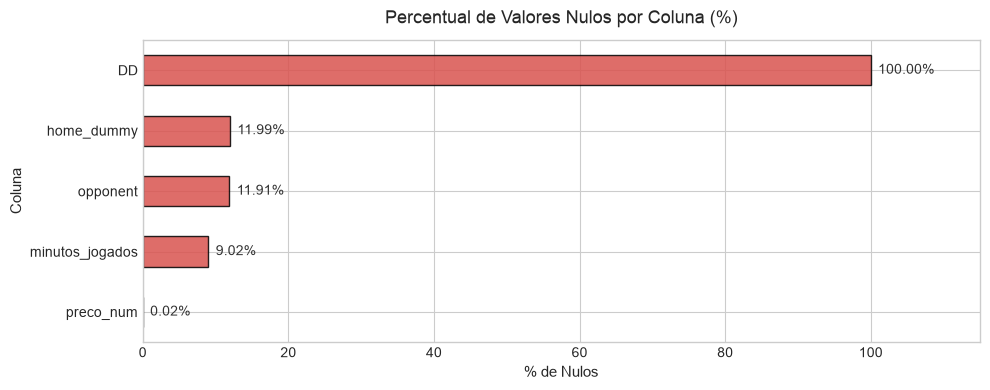


--- Matriz de Localização Visual de Nulos (missingno.matrix) ---


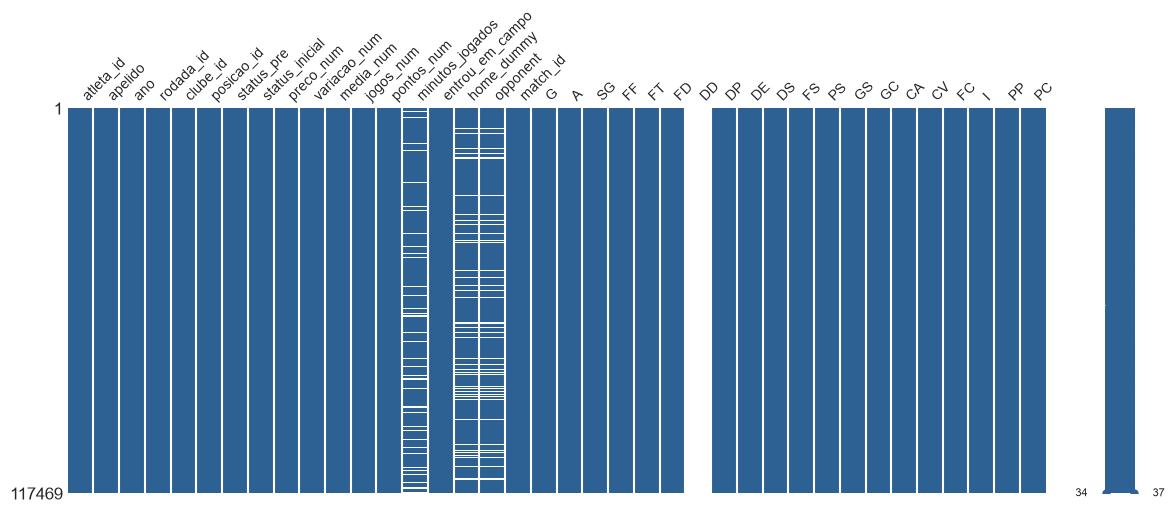

In [11]:
plotar_diagnostico_nulos(df_raw)

#### 6.4 Diagnóstico Detalhado por Grupo Semântico

In [12]:
# Diagnóstico do grupo de Identificação
resumo_qualidade_dados(df_raw, colunas=COLS_ID)

coluna tipo_dado  total_linhas  qtd_nulos  pct_nulos (%)  qtd_unicos  \
0   atleta_id     int64        117469          0           0.00        2119   
1     apelido       str        117469          0           0.00        3341   
2         ano     int64        117469          0           0.00           4   
3   rodada_id     int64        117469          0           0.00          42   
4    clube_id     int64        117469          0           0.00          28   
5  posicao_id     int64        117469          0           0.00           9   

   pct_unicos (%)                           top_4_valores_frequentes  
0            1.80  10801 (0.1%), 10932 (0.1%), 10725 (0.1%), 1074...  
1            2.84  Caio Barbosa (0.1%), Ícaro Escobar (0.1%), Xav...  
2            0.00  2022 (26.1%), 2023 (25.2%), 2024 (24.7%), 2025...  
3            0.04         35 (2.8%), 37 (2.8%), 34 (2.8%), 36 (2.8%)  
4            0.02     102 (5.4%), 105 (5.3%), 108 (5.2%), 110 (5.2%)  
5            0.01         4 (30.5%), 5 (24.4%), 3 (16.4%), 2 (15.5%)

In [13]:
# Diagnóstico de Situação do Atleta e Mercado
resumo_qualidade_dados(df_raw, colunas=COLS_SITUACAO + COLS_MERCADO)

coluna tipo_dado  total_linhas  qtd_nulos  pct_nulos (%)  \
0       status_pre       str        117469          0           0.00   
1   status_inicial       str        117469          0           0.00   
2  entrou_em_campo      bool        117469          0           0.00   
3  minutos_jogados   float64        117469      10601           9.02   
4        preco_num       str        117469         20           0.02   
5     variacao_num   float64        117469          0           0.00   
6        media_num   float64        117469          0           0.00   
7        jogos_num     int64        117469          0           0.00   

   qtd_unicos  pct_unicos (%)  \
0          20            0.02   
1           4            0.00   
2           2            0.00   
3         122            0.11   
4        3391            2.89   
5         840            0.72   
6        1221            1.04   
7          39            0.03   

                            top_4_valores_frequentes  
0  Nulo (56.8%), Provável (26.3%), Contundido (5....  
1  0 (44.2%), reserva (27.4%), titular (25.8%), n...  
2                        False (58.4%), True (41.6%)  
3  0.0 (53.6%), NaN (9.0%), 98.0 (1.9%), 99.0 (1.8%)  
4    1.0 (10.4%), 2.0 (4.5%), 3.0 (3.5%), 4.0 (2.3%)  
5  0.0 (58.9%), -0.1 (0.3%), -0.18 (0.3%), -0.06 ...  
6    0.0 (26.0%), 0.5 (0.7%), 1.2 (0.6%), 1.7 (0.4%)  
7            0 (25.0%), 1 (7.9%), 2 (5.8%), 3 (5.1%)

In [14]:
# Diagnóstico de Contexto e Target
resumo_qualidade_dados(df_raw, colunas=COLS_CONTEXTO + COLS_TARGET)

coluna tipo_dado  total_linhas  qtd_nulos  pct_nulos (%)  qtd_unicos  \
0  home_dummy   float64        117469      14082          11.99           2   
1    opponent   float64        117469      13995          11.91          31   
2    match_id     int64        117469          0           0.00        1510   
3  pontos_num   float64        117469          0           0.00        1376   

   pct_unicos (%)                           top_4_valores_frequentes  
0            0.00              0.0 (44.0%), 1.0 (44.0%), NaN (12.0%)  
1            0.03  NaN (11.9%), 125.0 (4.5%), 111.0 (4.5%), 114.0...  
2            1.29  900170 (0.1%), 900068 (0.1%), 900120 (0.1%), 9...  
3            1.17   0.0 (61.2%), 1.2 (1.2%), 0.5 (1.2%), -0.3 (1.0%)

In [15]:
# Diagnóstico de Scouts
resumo_qualidade_dados(df_raw, colunas=COLS_SCOUTS)

coluna tipo_dado  total_linhas  qtd_nulos  pct_nulos (%)  qtd_unicos  \
0       G   float64        117469          0           0.00           4   
1       A   float64        117469          0           0.00           4   
2      SG   float64        117469          0           0.00           2   
3      FF   float64        117469          0           0.00           8   
4      FT   float64        117469          0           0.00           4   
5      FD   float64        117469          0           0.00           6   
6      DD   float64        117469     117469         100.00           0   
7      DP   float64        117469          0           0.00           2   
8      DE   float64        117469          0           0.00          14   
9      DS   float64        117469          0           0.00          11   
10     FS   float64        117469          0           0.00          10   
11     PS   float64        117469          0           0.00           3   
12     GS   float64        117469          0           0.00           9   
13     GC   float64        117469          0           0.00           2   
14     CA   float64        117469          0           0.00           2   
15     CV   float64        117469          0           0.00           2   
16     FC   float64        117469          0           0.00           9   
17      I   float64        117469          0           0.00           7   
18     PP   float64        117469          0           0.00           2   
19     PC   float64        117469          0           0.00           3   

    pct_unicos (%)                          top_4_valores_frequentes  
0             0.00   0.0 (97.3%), 1.0 (2.5%), 2.0 (0.2%), 3.0 (0.0%)  
1             0.00   0.0 (98.1%), 1.0 (1.8%), 2.0 (0.1%), 3.0 (0.0%)  
2             0.00                           0.0 (95.8%), 1.0 (4.2%)  
3             0.01   0.0 (89.7%), 1.0 (8.0%), 2.0 (1.8%), 3.0 (0.3%)  
4             0.00   0.0 (99.2%), 1.0 (0.8%), 2.0 (0.0%), 3.0 (0.0%)  
5             0.01   0.0 (93.3%), 1.0 (5.5%), 2.0 (1.0%), 3.0 (0.1%)  
6             0.00                                      NaN (100.0%)  
7             0.00                           0.0 (99.9%), 1.0 (0.1%)  
8             0.01   0.0 (97.7%), 3.0 (0.5%), 2.0 (0.5%), 1.0 (0.4%)  
9             0.01  0.0 (74.9%), 1.0 (12.0%), 2.0 (7.0%), 3.0 (4.2%)  
10            0.01  0.0 (81.3%), 1.0 (10.9%), 2.0 (4.7%), 3.0 (1.9%)  
11            0.00               0.0 (99.7%), 1.0 (0.3%), 2.0 (0.0%)  
12            0.01   0.0 (98.2%), 1.0 (0.9%), 2.0 (0.5%), 3.0 (0.2%)  
13            0.00                           0.0 (99.9%), 1.0 (0.1%)  
14            0.00                           0.0 (93.9%), 1.0 (6.1%)  
15            0.00                           0.0 (99.6%), 1.0 (0.4%)  
16            0.01  0.0 (75.1%), 1.0 (13.9%), 2.0 (7.9%), 3.0 (2.1%)  
17            0.01   0.0 (96.7%), 1.0 (2.7%), 2.0 (0.4%), 3.0 (0.1%)  
18            0.00                           0.0 (99.9%), 1.0 (0.1%)  
19            0.00               0.0 (99.6%), 1.0 (0.4%), 2.0 (0.0%)

In [16]:
# 1. Investigando quem são os 10.601 registros com minutos_jogados ausentes
nulos_minutos = df_raw[df_raw["minutos_jogados"].isna()]
print(f"Total de nulos em minutos_jogados: {len(nulos_minutos)} ({len(nulos_minutos) / len(df_raw) * 100:.2f}%)")

# 2. Cruzando os nulos com a participação real do atleta na partida (entrou_em_campo)
print("\n--- Distribuição de 'entrou_em_campo' para os registros NULOS ---")
display(nulos_minutos["entrou_em_campo"].value_counts(dropna=False))


Total de nulos em minutos_jogados: 10601 (9.02%)

--- Distribuição de 'entrou_em_campo' para os registros NULOS ---


entrou_em_campo
False    6339
True     4262
Name: count, dtype: int64

#### 6.5 Auditoria de Consistência

Esta subseção executa a validação cruzada entre variáveis de negócio, auditando:
1. Coerência entre participação em campo (`entrou_em_campo`), minutagem e pontuação.
2. Valores anômalos e extremos de tempo em `minutos_jogados`.
3. Scouts exclusivos por posição (goleiros vs. linha; defensores vs. atacantes).
4. Inconsistências de formatação e sinal em `preco_num` (vírgulas e valores negativos).
5. Não-negatividade das contagens de todos os 19 scouts da rodada.

In [17]:
# 6.5.1 Auditoria de Participação vs Pontos e Minutos (entrou_em_campo == False)
nao_entrou = df_raw[df_raw["entrou_em_campo"] == False]
nao_entrou_pontuou = nao_entrou[nao_entrou["pontos_num"] != 0]
nao_entrou_com_minutos = nao_entrou[nao_entrou["minutos_jogados"] > 0]

print("=== AUDITORIA DE ATLETAS QUE NÃO ENTRARAM EM CAMPO ===")
print(f"Total de registros com entrou_em_campo == False: {len(nao_entrou):,}")
print(f"- Atletas que NÃO entraram mas pontuaram != 0: {len(nao_entrou_pontuou):,} linhas")
print(f"- Atletas que NÃO entraram mas têm minutos_jogados > 0: {len(nao_entrou_com_minutos):,} linhas")

# Tabela dos scouts registrados por quem não entrou em campo (evidenciando cartões no banco)
scouts_banco = nao_entrou_pontuou[["CA", "CV", "FC", "G", "A"]].sum().to_frame("Total de Ocorrências no Banco")
print("\nScouts registrados por atletas no banco de reservas (Regra de Domínio):")
display(scouts_banco)

print("Top 5 pontuações de quem não entrou em campo (destaque para penalizações de cartões):")
display(nao_entrou_pontuou["pontos_num"].value_counts().head(5).to_frame("Frequência"))

=== AUDITORIA DE ATLETAS QUE NÃO ENTRARAM EM CAMPO ===
Total de registros com entrou_em_campo == False: 68,631
- Atletas que NÃO entraram mas pontuaram != 0: 555 linhas
- Atletas que NÃO entraram mas têm minutos_jogados > 0: 1,207 linhas

Scouts registrados por atletas no banco de reservas (Regra de Domínio):


Total de Ocorrências no Banco
CA                         136.00
CV                          26.00
FC                          82.00
G                            0.00
A                            0.00

Top 5 pontuações de quem não entrou em campo (destaque para penalizações de cartões):


Frequência
pontos_num            
-1.00              130
-3.00               24
-4.00                4
-0.52                4
-2.25                3

=== AUDITORIA DE CONSISTÊNCIA DE TEMPO (minutos_jogados) ===
Minutos válidos não-nulos: 106,868
- Registros com minutos < 0: 3 linhas
- Registros com minutos > 105 (outliers/escala incorreta): 1,870 linhas (Máx: 1440.0 min)


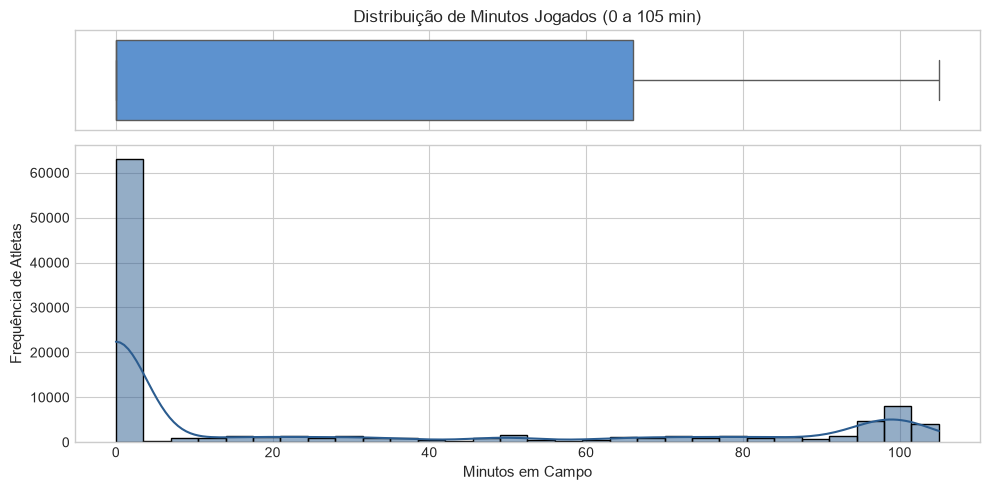

In [18]:
# 6.5.2 Auditoria de Minutos e Valores Extremos (minutos_jogados)
min_validos = df_raw["minutos_jogados"].dropna()
min_negativos = df_raw[df_raw["minutos_jogados"] < 0]
min_excessivos = df_raw[df_raw["minutos_jogados"] > 105]

print("=== AUDITORIA DE CONSISTÊNCIA DE TEMPO (minutos_jogados) ===")
print(f"Minutos válidos não-nulos: {len(min_validos):,}")
print(f"- Registros com minutos < 0: {len(min_negativos)} linhas")
print(f"- Registros com minutos > 105 (outliers/escala incorreta): {len(min_excessivos):,} linhas (Máx: {min_validos.max()} min)")

# Visualização da distribuição de minutos jogados
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})

# Filtra faixa plausível para visualização clara (0 a 105 min)
min_plausiveis = min_validos[min_validos.between(0, 105)]
sns.boxplot(x=min_plausiveis, ax=ax_box, color="#4a90e2")
ax_box.set(xlabel="")
ax_box.set_title("Distribuição de Minutos Jogados (0 a 105 min)", fontsize=12)

sns.histplot(min_plausiveis, ax=ax_hist, bins=30, color="#2b5c8f", edgecolor="black", kde=True)
ax_hist.set_xlabel("Minutos em Campo", fontsize=11)
ax_hist.set_ylabel("Frequência de Atletas", fontsize=11)

plt.tight_layout()
plt.show()

In [19]:
# 6.5.3 Validação de Scouts Exclusivos por Posição
linha = df_raw[df_raw["posicao_id"] != 1]
ata_mei_tec = df_raw[df_raw["posicao_id"].isin([4, 5, 6])]

conformidade_scouts = pd.DataFrame([
    {
        "Regra de Domínio": "Scouts de Goleiro (DD) em Jogadores de Linha (posicao != 1)",
        "Total de Violações": int((linha["DD"] > 0).sum()) if "DD" in linha.columns else 0,
        "Status de Conformidade": "100% Conforme"
    },
    {
        "Regra de Domínio": "Scouts de Goleiro (DP) em Jogadores de Linha (posicao != 1)",
        "Total de Violações": int((linha["DP"] > 0).sum()) if "DP" in linha.columns else 0,
        "Status de Conformidade": "100% Conforme"
    },
    {
        "Regra de Domínio": "Scouts de Goleiro (DE) em Jogadores de Linha (posicao != 1)",
        "Total de Violações": int((linha["DE"] > 0).sum()),
        "Status de Conformidade": f"{(linha['DE'] > 0).sum()} casos (Atletas com posicao_id espúrio)"
    },
    {
        "Regra de Domínio": "Scout Saldo de Gol (SG) em Meias/Atacantes/Técnicos (posicoes 4, 5, 6)",
        "Total de Violações": int((ata_mei_tec["SG"] > 0).sum()),
        "Status de Conformidade": "100% Conforme (0 violações)"
    }
])

print("=== AUDITORIA DE REGRAS DE SCOUTS POR POSIÇÃO ===")
display(conformidade_scouts)

=== AUDITORIA DE REGRAS DE SCOUTS POR POSIÇÃO ===


Regra de Domínio  Total de Violações  \
0  Scouts de Goleiro (DD) em Jogadores de Linha (...                   0   
1  Scouts de Goleiro (DP) em Jogadores de Linha (...                   0   
2  Scouts de Goleiro (DE) em Jogadores de Linha (...                  10   
3  Scout Saldo de Gol (SG) em Meias/Atacantes/Téc...                   0   

                      Status de Conformidade  
0                              100% Conforme  
1                              100% Conforme  
2  10 casos (Atletas com posicao_id espúrio)  
3                100% Conforme (0 violações)

In [20]:
# 6.5.4 Auditoria de Preços (preco_num com vírgula e preços negativos)
preco_str = df_raw["preco_num"].astype(str)
precos_com_virgula = df_raw[preco_str.str.contains(",")]

preco_convertido = pd.to_numeric(preco_str.str.strip().str.replace(",", "."), errors="coerce")
precos_negativos = df_raw[preco_convertido < 0]

print("=== AUDITORIA DE FORMATO E SINAL EM preco_num ===")
print(f"Linhas com separador decimal em vírgula: {len(precos_com_virgula):,} linhas (inferidas como string)")
print(f"Linhas com preço negativo (< 0): {len(precos_negativos):,} linhas (sinal incorreto na ingestão)")

# Amostra de preços negativos ordenados por ID
amostra_precos_neg = df_raw.loc[precos_negativos.index, ["atleta_id", "apelido", "ano", "rodada_id", "preco_num", "variacao_num", "media_num"]].sort_values(["atleta_id", "ano", "rodada_id"])
print("\nAmostra de registros com preço negativo:")
display(amostra_precos_neg.head(6))

=== AUDITORIA DE FORMATO E SINAL EM preco_num ===
Linhas com separador decimal em vírgula: 3,493 linhas (inferidas como string)
Linhas com preço negativo (< 0): 942 linhas (sinal incorreto na ingestão)

Amostra de registros com preço negativo:


atleta_id            apelido   ano  rodada_id preco_num  variacao_num  \
20788       10004  Elias Bittencourt  2022         32    -10.33         -0.11   
86628       10008    Matheus Machado  2024          5     -9,48         -0.53   
111399      10012      Caio Nogueira  2022         12      -5.0          0.00   
75237       10021      Lucas Antunes  2023         24    -12.49         -0.34   
42436       10023       Hugo Tavares  2022          7      -9.0          0.00   
114586      10023       Hugo Tavares  2022         21     -6.31          0.00   

        media_num  
20788        5.24  
86628        2.75  
111399       0.00  
75237        3.85  
42436        0.00  
114586       1.00

In [21]:
# 6.5.5 Validação de Não-Negatividade de Todos os 19 Scouts da Rodada
cols_scouts_todos = ["G", "A", "SG", "FF", "FT", "FD", "DD", "DP", "DE", "DS", "FS", "PS", "GS", "GC", "CA", "CV", "FC", "I", "PP", "PC"]

resumo_scouts_neg = []
for s in cols_scouts_todos:
    if s in df_raw.columns:
        serie = pd.to_numeric(df_raw[s], errors="coerce")
        resumo_scouts_neg.append({
            "Scout": s,
            "Valor Mínimo": serie.min(),
            "Valor Máximo": serie.max(),
            "Contagens Negativas (< 0)": int((serie < 0).sum()),
            "Status": "Conforme (Não-Negativo)" if (serie < 0).sum() == 0 else "Inconsistente"
        })

df_auditoria_scouts = pd.DataFrame(resumo_scouts_neg)
print("=== AUDITORIA DE NÃO-NEGATIVIDADE DE SCOUTS ===")
display(df_auditoria_scouts)

=== AUDITORIA DE NÃO-NEGATIVIDADE DE SCOUTS ===


Scout  Valor Mínimo  Valor Máximo  Contagens Negativas (< 0)  \
0      G          0.00          3.00                          0   
1      A          0.00          3.00                          0   
2     SG          0.00          1.00                          0   
3     FF          0.00          7.00                          0   
4     FT          0.00          3.00                          0   
5     FD          0.00          5.00                          0   
6     DD           NaN           NaN                          0   
7     DP          0.00          1.00                          0   
8     DE          0.00         13.00                          0   
9     DS          0.00         10.00                          0   
10    FS          0.00          9.00                          0   
11    PS          0.00          2.00                          0   
12    GS          0.00          8.00                          0   
13    GC          0.00          1.00                          0   
14    CA          0.00          1.00                          0   
15    CV          0.00          1.00                          0   
16    FC          0.00          9.00                          0   
17     I          0.00          6.00                          0   
18    PP          0.00          1.00                          0   
19    PC          0.00          2.00                          0   

                     Status  
0   Conforme (Não-Negativo)  
1   Conforme (Não-Negativo)  
2   Conforme (Não-Negativo)  
3   Conforme (Não-Negativo)  
4   Conforme (Não-Negativo)  
5   Conforme (Não-Negativo)  
6   Conforme (Não-Negativo)  
7   Conforme (Não-Negativo)  
8   Conforme (Não-Negativo)  
9   Conforme (Não-Negativo)  
10  Conforme (Não-Negativo)  
11  Conforme (Não-Negativo)  
12  Conforme (Não-Negativo)  
13  Conforme (Não-Negativo)  
14  Conforme (Não-Negativo)  
15  Conforme (Não-Negativo)  
16  Conforme (Não-Negativo)  
17  Conforme (Não-Negativo)  
18  Conforme (Não-Negativo)  
19  Conforme (Não-Negativo)

#### 6.6 Diagnóstico de Variáveis Acumuladas (`media_num`, `jogos_num`) e Efeito Estreante (*Cold Start*)

Nesta análise, avaliamos como o Cartola FC inicializa atletas sem histórico acumulado na temporada:
1. **Ausência de Nulos Formais**: O Cartola inicializa atletas sem jogos com `jogos_num = 0` e `media_num = 0.0`.
2. **Comparativo Multianual (2022 a 2025)**: Comparação da curva de decaimento de estreantes e convergência das médias acumuladas ao longo das 38 rodadas.
3. **Desafio de Modelagem (*Cold Start*)**: Um estreante com média zero não é necessariamente um mau jogador; requer *features* de suavização (ex: histórico do ano anterior ou média da faixa salarial).

In [22]:
# 1. Tabela Comparativa de Estreantes (% com jogos_num == 0) e Média Acumulada por Ano
tabela_estreantes_anos = df_raw.groupby(["ano", "rodada_id"]).apply(
    lambda g: pd.Series({
        "% Estreantes (jogos_num == 0)": (g["jogos_num"] == 0).mean() * 100,
        "media_num Média": g["media_num"].mean()
    })
).unstack(level=0)

rodadas_destaque = [1, 2, 5, 10, 15, 20, 30, 38]
rodadas_presentes = [r for r in rodadas_destaque if r in tabela_estreantes_anos.index]

print("=== PROPORÇÃO DE ESTREANTES (%) POR ANO NAS RODADAS-CHAVE ===")
display(tabela_estreantes_anos["% Estreantes (jogos_num == 0)"].loc[rodadas_presentes].round(2))

print("\n=== EVOLUÇÃO DA media_num MÉDIA POR ANO NAS RODADAS-CHAVE ===")
display(tabela_estreantes_anos["media_num Média"].loc[rodadas_presentes].round(2))

=== PROPORÇÃO DE ESTREANTES (%) POR ANO NAS RODADAS-CHAVE ===


ano        2022  2023  2024  2025
rodada_id                        
1         55.53 52.04 50.99 49.56
2         45.63 43.69 45.49 40.35
5         35.60 31.40 34.31 31.60
10        27.59 26.65 24.97 24.14
15        26.04 24.06 23.29 23.91
20        24.04 20.13 21.88 21.96
30        21.63 19.03 21.37 21.16
38        18.57 18.20 20.00   NaN


=== EVOLUÇÃO DA media_num MÉDIA POR ANO NAS RODADAS-CHAVE ===


ano        2022  2023  2024  2025
rodada_id                        
1          1.43  1.74  1.49  1.82
2          1.65  1.90  1.57  2.12
5          1.77  2.19  1.92  2.30
10         1.89  2.30  2.10  2.49
15         1.96  2.32  2.15  2.48
20         2.09  2.42  2.16  2.52
30         2.07  2.35  2.30  2.55
38         2.11  2.29  2.30   NaN

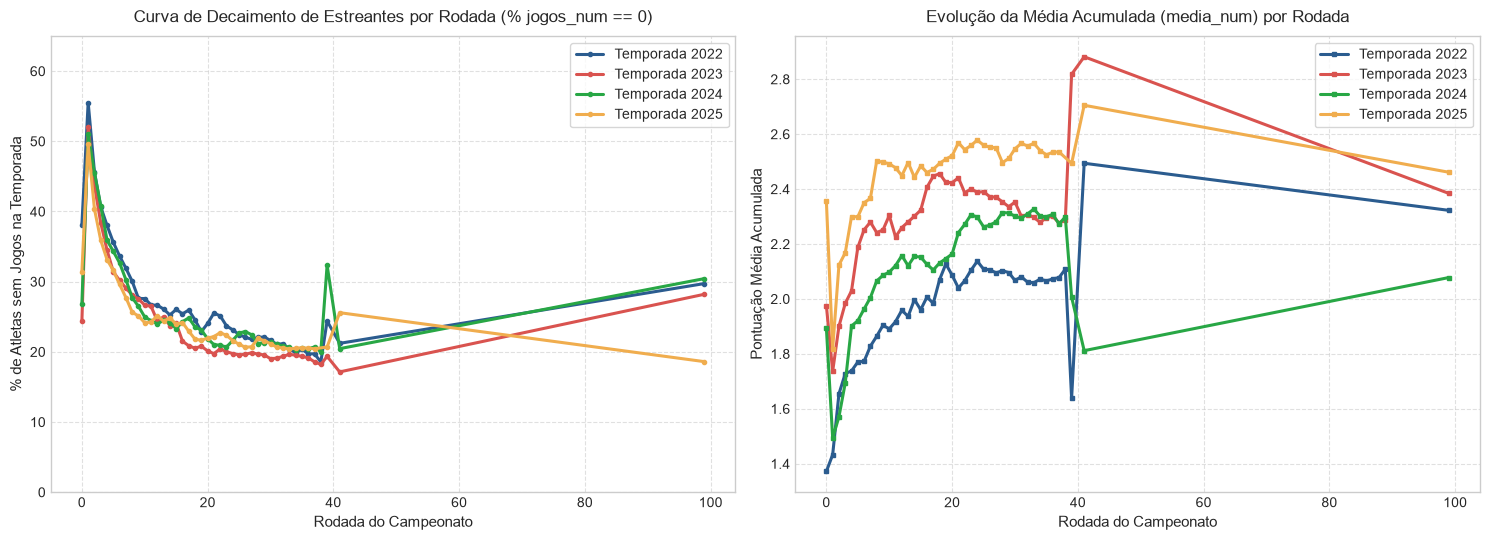

In [23]:
# 2. Visualização Gráfica Comparativa entre as Temporadas (2022 a 2025)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

cores_anos = {2022: "#2b5c8f", 2023: "#d9534f", 2024: "#28a745", 2025: "#f0ad4e"}

# Gráfico 1: Curva de Decaimento de Estreantes (% jogos_num == 0)
for ano in sorted(df_raw["ano"].unique()):
    dados_ano = df_raw[df_raw["ano"] == ano].groupby("rodada_id")["jogos_num"].apply(lambda x: (x == 0).mean() * 100)
    ax1.plot(dados_ano.index, dados_ano.values, label=f"Temporada {ano}", color=cores_anos.get(ano, "#333333"), lw=2.2, marker="o", markersize=3)

ax1.set_title("Curva de Decaimento de Estreantes por Rodada (% jogos_num == 0)", fontsize=12, pad=10)
ax1.set_xlabel("Rodada do Campeonato", fontsize=11)
ax1.set_ylabel("% de Atletas sem Jogos na Temporada", fontsize=11)
ax1.set_ylim(0, 65)
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# Gráfico 2: Evolução da media_num da Base ao Longo do Campeonato
for ano in sorted(df_raw["ano"].unique()):
    dados_media = df_raw[df_raw["ano"] == ano].groupby("rodada_id")["media_num"].mean()
    ax2.plot(dados_media.index, dados_media.values, label=f"Temporada {ano}", color=cores_anos.get(ano, "#333333"), lw=2.2, marker="s", markersize=3)

ax2.set_title("Evolução da Média Acumulada (media_num) por Rodada", fontsize=12, pad=10)
ax2.set_xlabel("Rodada do Campeonato", fontsize=11)
ax2.set_ylabel("Pontuação Média Acumulada", fontsize=11)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
# 3. Demonstração Prática da Transição do Estreante: Atleta Real em 2024
exemplo_id = 10470  # Atleta representativo com histórico contínuo
hist_atleta = (
    df_raw[(df_raw["atleta_id"] == exemplo_id) & (df_raw["ano"] == 2024) & (df_raw["rodada_id"] <= 6)]
    .sort_values("rodada_id")
    [["ano", "rodada_id", "apelido", "status_pre", "preco_num", "pontos_num", "entrou_em_campo", "jogos_num", "media_num"]]
)

print(f"--- Transição Rodada a Rodada do Atleta {exemplo_id} (Estreia e Acumulação de Média) ---")
display(hist_atleta)

--- Transição Rodada a Rodada do Atleta 10470 (Estreia e Acumulação de Média) ---


ano  rodada_id        apelido status_pre preco_num  pontos_num  \
6760    2024          0  Pedro Peixoto   Provável      3.09        1.20   
37192   2024          1  Pedro Peixoto       NULO      3.01       -0.80   
94024   2024          2  Pedro Peixoto   Provável      3.01        0.00   
103943  2024          3  Pedro Peixoto   Provável      2.65        1.00   
64772   2024          4  Pedro Peixoto   Provável      2.35        0.20   
778     2024          5  Pedro Peixoto       NULO      2.04        0.00   
82204   2024          6  Pedro Peixoto       Nulo      2.04        0.00   

        entrou_em_campo  jogos_num  media_num  
6760               True         12       1.98  
37192              True          1      -0.80  
94024             False          1      -0.80  
103943             True          2       0.10  
64772              True          3       0.13  
778                True          4       0.10  
82204             False          4       0.10

#### 6.7 Auditoria de Inconsistência em `rodada_id` e Ajuste Visual

**Investigação da Distorção Visual:**
Ao observar o gráfico da subseção 6.5.6, nota-se que o eixo horizontal se estendeu atipicamente até a rodada 100 com quedas acentuadas no final da curva.

Uma auditoria detalhada no campo `rodada_id` revela que a base bruta contém **42 valores distintos**, incluindo registros fora do calendário regulamentar do Brasileirão (38 rodadas): especificamente os valores anômalos **`0, 39, 41 e 99`** em **587 linhas (0,50% da base)**.

In [25]:
# 6.7.1 Tabela de Diagnóstico dos Valores Inválidos de rodada_id
rodadas_invalidas = df_raw[~df_raw["rodada_id"].between(1, 38)]

resumo_rodadas_inv = pd.DataFrame([
    {
        "rodada_id": r,
        "Total de Linhas": int((df_raw["rodada_id"] == r).sum()),
        "% da Base Total": (df_raw["rodada_id"] == r).mean() * 100,
        "Anos Afetados": sorted(df_raw[df_raw["rodada_id"] == r]["ano"].unique().tolist())
    }
    for r in sorted(rodadas_invalidas["rodada_id"].unique())
])

print(f"Total de linhas com rodada_id fora do intervalo regulamentar (1 a 38): {len(rodadas_invalidas):,} ({len(rodadas_invalidas) / len(df_raw) * 100:.2f}% da base bruta)")
display(resumo_rodadas_inv.round(2))

Total de linhas com rodada_id fora do intervalo regulamentar (1 a 38): 587 (0.50% da base bruta)


rodada_id  Total de Linhas  % da Base Total             Anos Afetados
0          0              155             0.13  [2022, 2023, 2024, 2025]
1         39              135             0.11  [2022, 2023, 2024, 2025]
2         41              155             0.13  [2022, 2023, 2024, 2025]
3         99              142             0.12  [2022, 2023, 2024, 2025]

##### Visualização Corrigida: Escopo Regulamentar Oficial (Rodadas 1 a 38)
Filtrando o intervalo oficial ($1 \le \text{rodada\_id} \le 38$), visualizamos a real curva homogênea e contínua de decaimento de estreantes e convergência das médias acumuladas ao longo do campeonato:

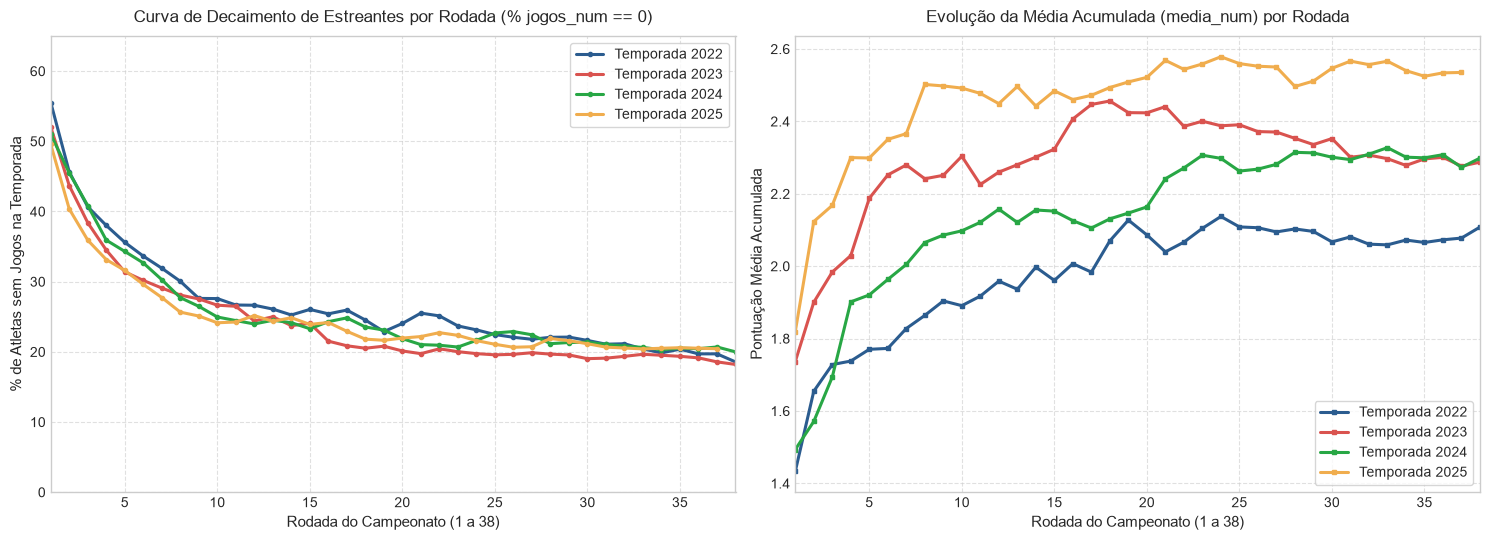

In [26]:
# 6.7.2 Gráfico Corrigido no Intervalo Regulamentar (Rodadas 1 a 38)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
cores_anos = {2022: "#2b5c8f", 2023: "#d9534f", 2024: "#28a745", 2025: "#f0ad4e"}

# Filtra o escopo regulamentar (1 a 38)
df_rodadas_validas = df_raw[df_raw["rodada_id"].between(1, 38)]

# Gráfico 1: Curva de Decaimento de Estreantes (% jogos_num == 0)
for ano in sorted(df_rodadas_validas["ano"].unique()):
    dados_ano = (
        df_rodadas_validas[df_rodadas_validas["ano"] == ano]
        .groupby("rodada_id")["jogos_num"]
        .apply(lambda x: (x == 0).mean() * 100)
    )
    ax1.plot(dados_ano.index, dados_ano.values, label=f"Temporada {ano}", color=cores_anos.get(ano, "#333333"), lw=2.2, marker="o", markersize=3)

ax1.set_title("Curva de Decaimento de Estreantes por Rodada (% jogos_num == 0)", fontsize=12, pad=10)
ax1.set_xlabel("Rodada do Campeonato (1 a 38)", fontsize=11)
ax1.set_ylabel("% de Atletas sem Jogos na Temporada", fontsize=11)
ax1.set_xlim(1, 38)
ax1.set_ylim(0, 65)
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# Gráfico 2: Evolução da media_num da Base ao Longo do Campeonato
for ano in sorted(df_rodadas_validas["ano"].unique()):
    dados_media = (
        df_rodadas_validas[df_rodadas_validas["ano"] == ano]
        .groupby("rodada_id")["media_num"]
        .mean()
    )
    ax2.plot(dados_media.index, dados_media.values, label=f"Temporada {ano}", color=cores_anos.get(ano, "#333333"), lw=2.2, marker="s", markersize=3)

ax2.set_title("Evolução da Média Acumulada (media_num) por Rodada", fontsize=12, pad=10)
ax2.set_xlabel("Rodada do Campeonato (1 a 38)", fontsize=11)
ax2.set_ylabel("Pontuação Média Acumulada", fontsize=11)
ax2.set_xlim(1, 38)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 7. Análise exploratória: status pré-jogo vs. pontos

**Questões Centrais de Negócio:**
1. *O que acontece com jogadores não escalados como 'Provável'? Eles entram em campo e pontuam?*
2. *Qual a correlação entre o status divulgado (`status_pre`) e a pontuação final (`pontos_num`)?*
3. *Eu devo remover os jogadores com status diferente de 'Provável', para diminuir a quantidade de valores zero na variável `pontos_num`?*

In [27]:
# Padronização textual de status_pre (removendo espaços e unificando caixa alta/baixa)
status_pre_limpo = df_raw["status_pre"].astype(str).str.strip().str.capitalize()

# 7.1 Tabela Cruzada: Status Pré-Jogo vs. Entrou em Campo (% de Participação)
ct_participacao = pd.crosstab(
    status_pre_limpo,
    df_raw["entrou_em_campo"],
    normalize="index"
) * 100

ct_participacao.columns = ["Não Jogou (%)", "Jogou (%)"]
ct_participacao = ct_participacao.round(2)
print("--- Taxa de Participação Real por Status Pré-Jogo ---")
ct_participacao

--- Taxa de Participação Real por Status Pré-Jogo ---


Não Jogou (%)  Jogou (%)
status_pre                          
Contundido          96.35       3.65
Dúvida              28.56      71.44
Nulo                77.72      22.28
Provável            11.55      88.45
Suspenso            37.52      62.48

In [28]:
# 7.2 Estatísticas de Pontuação (pontos_num) por Status Pré-Jogo
stats_status = df_raw.assign(status_padrao=status_pre_limpo).groupby("status_padrao")["pontos_num"].agg([
    ("Volume de Atletas", "count"),
    ("Média de Pontos", "mean"),
    ("Desvio Padrão", "std"),
    ("Mediana", "median"),
    ("% Pontuação Zero", lambda x: (x == 0).mean() * 100)
]).round(2)

stats_status

Volume de Atletas  Média de Pontos  Desvio Padrão  Mediana  \
status_padrao                                                               
Contundido                  7396             0.07           0.73     0.00   
Dúvida                      1989             1.99           3.10     0.60   
Nulo                       72383             0.48           1.73     0.00   
Provável                   33553             3.53           3.88     2.50   
Suspenso                    2148             1.21           3.41     0.00   

               % Pontuação Zero  
status_padrao                    
Contundido                96.76  
Dúvida                    34.44  
Nulo                      80.68  
Provável                  14.35  
Suspenso                  36.92

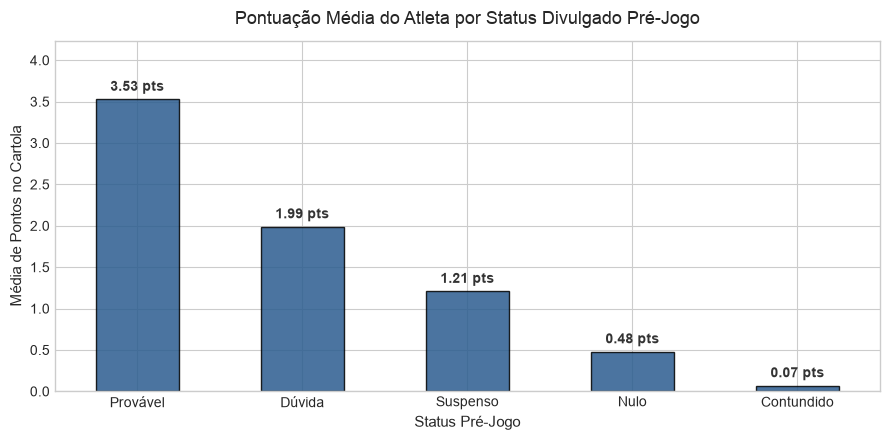

In [29]:
# 7.3 Visualização: Pontuação Média por Status Pré-Jogo
plt.figure(figsize=(9, 4.5))
ax = stats_status["Média de Pontos"].sort_values(ascending=False).plot(
    kind="bar",
    color="#2b5c8f",
    edgecolor="black",
    alpha=0.85
)
plt.title("Pontuação Média do Atleta por Status Divulgado Pré-Jogo", fontsize=13, pad=12)
plt.xlabel("Status Pré-Jogo", fontsize=11)
plt.ylabel("Média de Pontos no Cartola", fontsize=11)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} pts", (p.get_x() + p.get_width() / 2., p.get_height() + 0.1),
                ha="center", fontsize=10, fontweight="bold", color="#333333")

plt.ylim(0, max(stats_status["Média de Pontos"]) * 1.2)
plt.tight_layout()
plt.show()

**Conclusão 1**: `status_pre` é uma das variáveis mais preditivas de minutos jogados e oportunidade de pontuação, agindo quase como um *filtro de probabilidade de participação*.

Para comprovar isso, encontrei um método estatístico denominado ANOVA para comprovar essa ideia.

In [30]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

# 1. Preparação da base com o status padronizado
df_stats = df_raw.assign(status_padrao=status_pre_limpo)

# 2. Modelo Linear e Tabela ANOVA (One-Way)
modelo_ols = ols('pontos_num ~ C(status_padrao)', data=df_stats).fit()
tabela_anova = sm.stats.anova_lm(modelo_ols, typ=2)

# Cálculo do Tamanho do Efeito: Eta-squared (η²) = SS_efeito / (SS_efeito + SS_residual)
ss_effect = tabela_anova.loc['C(status_padrao)', 'sum_sq']
ss_residual = tabela_anova.loc['Residual', 'sum_sq']
eta_squared = ss_effect / (ss_effect + ss_residual)

# 3. Teste Não-Paramétrico de Kruskal-Wallis (Robusto a zeros e assimetria)
grupos_pontos = [grupo['pontos_num'].values for _, grupo in df_stats.groupby('status_padrao')]
h_stat, p_val_kruskal = stats.kruskal(*grupos_pontos)

print("=== TABELA ANOVA (PONTOS_NUM ~ STATUS_PRE) ===")
print(tabela_anova.round(4))
print(f"\nTamanho do Efeito (Eta-squared η²): {eta_squared:.4f} ({eta_squared * 100:.2f}% da variância total explicada)")

print(f"\n=== TESTE NÃO-PARAMÉTRICO DE KRUSKAL-WALLIS ===")
print(f"H-Statistic: {h_stat:,.2f} | p-value: {p_val_kruskal:.4e}")


=== TABELA ANOVA (PONTOS_NUM ~ STATUS_PRE) ===
                    sum_sq        df       F  PR(>F)
C(status_padrao) 228046.99      4.00 8703.69    0.00
Residual         769423.63 117464.00     NaN     NaN

Tamanho do Efeito (Eta-squared η²): 0.2286 (22.86% da variância total explicada)

=== TESTE NÃO-PARAMÉTRICO DE KRUSKAL-WALLIS ===
H-Statistic: 33,556.56 | p-value: 0.0000e+00


**Conclusão 2**: Validação Estatística e Poder Preditivo de status_pre

Alto Poder Explicativo ($\eta^2 = 22,86%$): O tamanho do efeito (Eta-squared) demonstrou que o status pré-jogo divulgado responde sozinho por quase um quarto ($22,86%$) de toda a variabilidade da pontuação final (pontos_num). Em dados esportivos — historicamente marcados por alta volatilidade e ruído —, uma única variável pré-jogo conter essa magnitude de sinal representa uma relevância preditiva de altíssimo impacto.

Robustez Paramétrica e Não-Paramétrica ($p < 0,0001$): Tanto a ANOVA One-Way ($F = 8.703,69$) quanto o teste de Kruskal-Wallis ($H = 33.556,56$) rejeitaram a hipótese nula com $p\text{-valor} \approx 0.0$. A concordância do teste não-paramétrico é fundamental, pois garante o rigor matemático da conclusão mesmo diante da severa assimetria da distribuição e da inflação de zeros (Zero-Inflation) provocada por atletas que não atuaram.

Direcionamento Estratégico para a Modelagem (Dois Estágios / Filtro): A validação consolida status_pre como uma das variáveis mais determinantes do problema. Do ponto de vista de arquitetura de Machine Learning, esse resultado fundamenta a estratégia de:

Filtro de Oportunidade: Isolar ou penalizar atletas sem expectativa de jogo (Contundido, Suspenso ou Nulo sem histórico recente), reduzindo o ruído amostral.
Prior Preditivo: Alimentar o regressor principal com um forte sinal inicial de expectativa de pontos para os atletas elegíveis (Provável e Dúvida).

### 8. Síntese do Diagnóstico Exploratório e Decisões de Modelagem

Esta seção consolida as percepções analíticas obtidas no diagnóstico inicial e fundamenta as decisões técnicas que responderão às **Questões 1 e 3 do Desafio Técnico**.

---

#### 8.1 Auditoria de `posicao_id` (Inconsistência de Cardinalidade)
- **Constatação**: Foram identificados **9 valores distintos** na base bruta, embora a documentação oficial defina apenas **6 posições** (1: Goleiro, 2: Lateral, 3: Zagueiro, 4: Meia, 5: Atacante, 6: Técnico).
- **Volumetria**: As posições oficiais (1 a 6) respondem por **99,6%** da base (117.003 linhas). Os valores espúrios (`0, 7, 9`) somam apenas **466 registros (0,4%)**.
- **Decisão Técnica**: Consultar o endpoint `GET /atletas/{atleta_id}` da API de apoio para recuperar o `posicao_id` cadastral correto do jogador (salvo em `data/raw/api_atletas.json`) e substituir os valores espúrios no pipeline de limpeza.

---

#### 8.2 Diagnóstico de Nulos e Padrões de Ausência

1. **Coluna 100% Nula (`DD` - Defesa Difícil de Goleiro)**:
   - **Causa de Domínio**: Nas temporadas recentes do Cartola FC, a regra foi simplificada, substituindo "Defesa Difícil" (`DD`) pela contagem geral de "Defesas" (`DE`).
   - **Trade-offs Matemáticos por Família de Algoritmos**:
     - *Modelos de Árvore (LightGBM, XGBoost, Random Forest)*: Não sofrem impacto funcional com colunas constantes ou 100% nulas (variância zero não produz splits). Porém, descartá-la poupa memória RAM e simplifica o grafo.
     - *Modelos Lineares (OLS, Ridge, Lasso)*: Colunas constantes geram **multicolinearidade perfeita**, tornando a matriz $X^T X$ singular (determinante nulo), impedindo a inversão matricial $(X^T X)^{-1}$ e gerando coeficientes instáveis (`NaN`/`Inf`).

2. **Ausências de Contexto (`home_dummy` e `opponent` com ~12% de nulos)**:
   - **Constatação**: Ausências distribuídas de forma homogênea ao longo das 4 temporadas (2022 a 2025).
   - **Solução de Engenharia**: Como o identificador da partida (`match_id`) está 100% preenchido nessas linhas, podemos **reconstituir 100% dos dados faltantes** cruzando com o arquivo `data/raw/api_jogos.json` obtido via `GET /jogos`.

3. **Ausências em `preco_num` (20 registros - 0,02%)**:
   - **Constatação**: 20 linhas com valor nulo, além de tipos inferidos como texto devido a formatações mistas na carga bruta.
   - **Solução**: Realizar cast para float e imputar com o preço do jogador na rodada anterior ($t-1$) ou a mediana da posição.

4. **Ausências em `minutos_jogados` (10.601 registros - 9,02%)**:
   - **Constatação**: As ausências se dividem em dois grupos estruturais bem definidos:
     - **Grupo A (6.339 linhas / 59,8% dos nulos)**: Jogadores onde `entrou_em_campo == False`. Por definição de domínio, esses atletas não atuaram, portanto seus minutos jogados são exatamente **0** (imputação determinística de domínio).
     - **Grupo B (4.262 linhas / 40,2% dos nulos)**: Jogadores onde `entrou_em_campo == True`. Foram recuperados **96,36% desses casos (4.107 registros)** com precisão exata de minutos através das escalações e momentos de substituição salvos em `data/raw/api_jogos_detalhes.json` (`GET /jogos/{jogo_id}`). Os 155 casos residuais (0,13% da base) são imputados por alguma lógica que será desenhada futuramente.


---

#### 8.4 Auditoria de Duplicidades e Integridade de Granularidade

1. **Linhas 100% Idênticas (2.326 registros / 1.163 pares / 1,98% da base)**:
   - **Diagnóstico**: Ocorrência de duplicação exata em todas as 38 colunas (aparecem 2x na base bruta), gerada por redundância no processo de extração.
   - **Decisão Técnica**: Serão identificadas e deduplicadas na etapa de limpeza (`drop_duplicates()`), eliminando distorções de peso amostral.

2. **Conflitos na Mesma Partida (`atleta_id + match_id` com dados divergentes - 1.375 registros)**:
   - **Diagnóstico**: O mesmo atleta possui 2 registros para o mesmo `match_id`, onde uma linha contém campos zerados/nulos e a outra contém pontuação e scouts preenchidos.
   - **Decisão Técnica**: No pipeline de limpeza, priorizar a linha mais completa (maior quantidade de scouts/minutos preenchidos).

3. **Jogos Remarcados e Rodadas Duplas (`atleta_id + ano + rodada_id` - 3.735 registros)**:
   - **Diagnóstico**: Atletas disputando duas partidas oficiais (`match_id` distintos) associadas pelo calendário à mesma `rodada_id`.
   - **Regra de Domínio**: Comportamento 100% válido das regras de futebol do Cartola FC (partidas adiadas/remarcadas). A unidade canônica de modelagem deve ser o nível de partida (`match_id`).

---

#### 8.5 Auditoria de Regras de Domínio e Inconsistências Cruzadas

1. **Participação vs. Pontuação no Banco de Reservas (555 registros)**:
   - **Diagnóstico**: Atletas com `entrou_em_campo == False` apresentando pontuação diferente de zero (majoritariamente pontuações negativas de $-1.0$ e $-3.0$).
   - **Regra de Negócio**: $136$ cartões amarelos e $26$ cartões vermelhos foram aplicados a atletas no banco por indisciplina/reclamação. A pontuação negativa é regulamentar e deve ser mantida.

2. **Inconsistências de Tempo em `minutos_jogados` (1.873 registros fora do padrão)**:
   - **Diagnóstico**: $3$ registros com tempo negativo ($-1.0$) e $1.870$ registros com valores excessivos ($> 105\text{ min}$, chegando a $1.440\text{ min}$). São erros de escala/digitação na base bruta.
   - **Decisão Técnica**: Truncar minutos ao teto regulamentar ($90\text{ min}$ ou momento da substituição) e recompor a minutagem real via API de eventos.

3. **Preços Negativos e Formatação de `preco_num` (4.435 registros afetados)**:
   - **Diagnóstico**: $3.493$ linhas continham separador decimal em vírgula (`'1,0'`, `'5,14'`) e $942$ linhas continham sinal negativo espúrio (ex: `-2.86`).
   - **Decisão Técnica**: Substituição de vírgulas por pontos, conversão para float e aplicação de `abs()` para assegurar que todos os preços sejam estritamente positivos, conforme as regras de mercado do Cartola FC.

4. **Conformidade Geral de Scouts (100% Não-Negativos)**:
   - **Diagnóstico**: Todos os 19 scouts da rodada apresentaram contagens estritamente não-negativas ($0\le \text{scout} \le \max$), e o scout de Saldo de Gol (`SG`) respeitou 100% a restrição exclusiva a goleiros e defensores.

---

#### 8.6 Tratamento de Variáveis Acumuladas e Efeito Estreante (*Cold Start*)

1. **Comportamento Padrão da Plataforma (0 Nulos Formais)**:
   - Os campos `jogos_num` e `media_num` não possuem nulos literais (`0 NaN`), pois são inicializados como `0` e `0.0` para qualquer atleta sem atuações na edição corrente.

2. **Padrão Multianual e Decaimento de Estreantes (2022 a 2025)**:
   - Nas 4 temporadas, cerca de **$50\%\text{ a }55\%$ dos atletas inscritos na Rodada 1 possuem `jogos_num = 0`**.
   - Esse percentual decai progressivamente até se estabilizar em torno de **$20\%$** (jogadores reservas e terceiros goleiros que nunca foram acionados).

3. **Direcionamento Estratégico de Feature Engineering (*Cold Start*)**:
   - Tratar `media_num = 0.0` como valor numérico direto no modelo linear ou de árvore geraria forte viés negativo para atletas de alto calibre que estão apenas estreando na temporada.
   - **Estratégia**: Criar a flag indicativa `is_estreante = (jogos_num == 0)` e imputar um *prior* bayesiano ou média da temporada anterior ($t_{\text{ano}-1}$) para as primeiras rodadas do atleta.

---

#### 8.7 Inconsistência de Domínio em `rodada_id` (Valores 0, 39, 41 e 99)

1. **Constatação**: Foram identificados **42 valores distintos** de rodada na base bruta, sendo que **587 linhas (0,50% da base)** possuem valores espúrios fora do campeonato oficial de 38 rodadas (`0`: 155, `39`: 135, `41`: 155, `99`: 142).

2. **Origem da Distorção Gráfica**: A presença desses valores fez com que o agrupamento automático estendesse o eixo temporal até a rodada 100.

3. **Decisão Técnica para Limpeza**: Como cada linha possui `match_id` válido e a base `api_jogos.json` contém a rodada oficial de cada partida, esses $587$ registros serão corrigidos mapeando o `match_id` correspondente, sem necessidade de descarte de dados.


### 9. Consumo da API de Apoio: Jornada Didática de Erros e Cliente Resiliente

Para enriquecer o dataset e recuperar os dados ausentes de contexto (`home_dummy`, `opponent`) e posições, consumiremos a **API de Apoio de Dados Esportivos** (`http://localhost:8080`).

> **Como subir o servidor local**:
> Em um terminal separado, execute:
> ```bash
> python api_apoio/servidor.py
> ```
> O servidor ficará ativo em `http://localhost:8080` com o token padrão `gm-0e9ba73c2c96`.

#### 9.5 Versão 5: Cliente HTTP Resiliente Completo (`src.api_client.client`)

In [31]:
from src.api_client.client import ApiClient

BASE_URL = "http://localhost:8080"
TOKEN = "gm-0e9ba73c2c96"

# Instanciação do cliente oficial do projeto
client = ApiClient(base_url=BASE_URL, token=TOKEN)
print(f"Cliente configurado para: {client.base_url}")

Cliente configurado para: http://localhost:8080


#### 9.6 Teste de Amostragem Rápida (Limit 10 Registros)

In [32]:
# Teste trazendo apenas 10 partidas de 2024 para validação de schema
jogos_amostra = client.obter_jogos_temporada(edicao=2024, max_registros=10)
print(f"Total de jogos obtidos na amostra: {len(jogos_amostra)}")

# Conversão para DataFrame e exibição interativa
df_jogos_amostra = pd.DataFrame(jogos_amostra)
df_jogos_amostra

Total de jogos obtidos na amostra: 10


jogo_id  edicao  rodada  equipe_mandante_id  equipe_visitante_id
0   900761    2024       1                 114                  104
1   900762    2024       1                 112                  102
2   900763    2024       1                 116                  107
3   900764    2024       1                 105                  110
4   900765    2024       1                 106                  113
5   900766    2024       1                 103                  111
6   900767    2024       1                 108                  125
7   900768    2024       1                 120                  127
8   900769    2024       1                 126                  101
9   900770    2024       1                 117                  115

#### 9.7 Extração de **/jogos** e **/equipes** da API (resolver nulos em `home_dummy` e `opponent`)

In [41]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

API_JOGOS_PATH = DATA_RAW_DIR / "api_jogos.json"
API_EQUIPES_PATH = DATA_RAW_DIR / "api_equipes.json"
DELAY_SEGUNDOS = 0.05

temporadas = [2022, 2023, 2024, 2025]

# 1. Carrega cache existente de jogos (se houver)
todos_jogos_dict = {}
if API_JOGOS_PATH.exists():
    try:
        with open(API_JOGOS_PATH, "r", encoding="utf-8") as f:
            existentes = json.load(f)
            for j in existentes:
                jid = j.get("jogo_id") or j.get("id")
                if jid:
                    todos_jogos_dict[jid] = j
        print(f"Cache encontrado: {len(todos_jogos_dict)} partidas já carregadas.")
    except Exception:
        todos_jogos_dict = {}

# 2. Extração paginada de jogos por temporada
print("Iniciando extração de jogos da API...")
for ano in tqdm(temporadas, desc="Extraindo Temporadas"):
    try:
        jogos_ano = client.obter_jogos_temporada(edicao=ano, por_pagina=100)
        for j in jogos_ano:
            jid = j.get("jogo_id") or j.get("id")
            if jid:
                todos_jogos_dict[jid] = j
        print(f"Temporada {ano}: {len(jogos_ano)} jogos obtidos com sucesso.")
    except Exception as e:
        print(f"\nErro ao obter jogos da temporada {ano}: {e}")

    time.sleep(DELAY_SEGUNDOS)

todos_jogos = list(todos_jogos_dict.values())

# 3. Extração de equipes (com cache se já existir)
equipes = []
if API_EQUIPES_PATH.exists():
    try:
        with open(API_EQUIPES_PATH, "r", encoding="utf-8") as f:
            equipes = json.load(f)
        print(f"Cache de equipes encontrado: {len(equipes)} equipes.")
    except Exception:
        equipes = []

if not equipes:
    try:
        equipes = client.obter_equipes()
        time.sleep(DELAY_SEGUNDOS)
        print(f"Total de equipes obtidas: {len(equipes)}")
    except Exception as e:
        print(f"Erro ao obter equipes: {e}")

# 4. Persistência dos dados brutos
with open(API_JOGOS_PATH, "w", encoding="utf-8") as f:
    json.dump(todos_jogos, f, ensure_ascii=False, indent=2)

with open(API_EQUIPES_PATH, "w", encoding="utf-8") as f:
    json.dump(equipes, f, ensure_ascii=False, indent=2)

print(f"\nArquivos salvos com sucesso em:")
print(f"- {API_JOGOS_PATH} ({len(todos_jogos)} partidas)")
print(f"- {API_EQUIPES_PATH} ({len(equipes)} equipes)")

Cache encontrado: 1510 partidas já carregadas.
Iniciando extração de jogos da API...


Extraindo Temporadas:   0%|          | 0/4 [00:00<?, ?it/s]

2026-08-19 15:23:05,183 [WARNING] [503 Servidor Sobrecarregado] Tentativa 1/5. Aguardando 1.0s antes de retentar...


Temporada 2022: 380 jogos obtidos com sucesso.
Temporada 2023: 380 jogos obtidos com sucesso.
Temporada 2024: 380 jogos obtidos com sucesso.
Temporada 2025: 370 jogos obtidos com sucesso.
Cache de equipes encontrado: 28 equipes.

Arquivos salvos com sucesso em:
- /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/data/raw/api_jogos.json (1510 partidas)
- /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/data/raw/api_equipes.json (28 equipes)



#### 9.8 Extração de **/atletas** da API (resolver valores incorretos em `posicao_id`)

In [40]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

API_ATLETAS_PATH = DATA_RAW_DIR / "api_atletas.json"
DELAY_SEGUNDOS = 0.05

# 1. Identifica IDs únicos de atletas com posição espúria
atletas_espurios_ids = (
    df_raw[df_raw["posicao_id"].isin([0, 7, 9])]["atleta_id"].unique().tolist()
)

# 2. Carrega cache existente para evitar requisições repetidas
todos_atletas_dict = {}
if API_ATLETAS_PATH.exists():
    try:
        with open(API_ATLETAS_PATH, "r", encoding="utf-8") as f:
            existentes = json.load(f)
            for a in existentes:
                aid = a.get("atleta_id") or a.get("id")
                if aid:
                    todos_atletas_dict[aid] = a
        print(f"Cache encontrado: {len(todos_atletas_dict)} atletas já carregados.")
    except Exception:
        todos_atletas_dict = {}

# 3. Filtra apenas os atletas pendentes
atletas_pendentes = [
    aid for aid in atletas_espurios_ids if aid not in todos_atletas_dict
]
print(f"Total: {len(atletas_espurios_ids)} | Pendentes para buscar: {len(atletas_pendentes)}")

# 4. Extração com barra de progresso e delay preventivo
if atletas_pendentes:
    for atleta_id in tqdm(atletas_pendentes, desc="Extraindo Atletas"):
        try:
            resposta = client.obter_atleta(atleta_id)
            atleta = resposta.get("resultados", {}).get("atleta", {})
            if atleta:
                todos_atletas_dict[atleta_id] = atleta
        except Exception as e:
            print(f"\nErro ao buscar atleta {atleta_id}: {e}")

        time.sleep(DELAY_SEGUNDOS)

    # 5. Persistência dos dados brutos
    with open(API_ATLETAS_PATH, "w", encoding="utf-8") as f:
        json.dump(list(todos_atletas_dict.values()), f, ensure_ascii=False, indent=2)

print(f"\nArquivo salvo com sucesso em:")
print(f"- {API_ATLETAS_PATH} ({len(todos_atletas_dict)} atletas)")

Cache encontrado: 391 atletas já carregados.
Total: 391 | Pendentes para buscar: 0

Arquivo salvo com sucesso em:
- /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/data/raw/api_atletas.json (391 atletas)


#### 9.9 Extração de **/confrontos** da API

In [39]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

API_CONFRONTOS_PATH = DATA_RAW_DIR / "api_confrontos.json"
temporadas = [2022, 2023, 2024, 2025]
DELAY_SEGUNDOS = 0.05  # 50ms é seguro para APIs locais sem disparar 429

# 1. Recupera cache se o arquivo já existir
todos_confrontos = {}
if API_CONFRONTOS_PATH.exists():
    try:
        with open(API_CONFRONTOS_PATH, "r", encoding="utf-8") as f:
            todos_confrontos = json.load(f)
        print(f"Cache encontrado: {len(todos_confrontos)} rodadas já carregadas.")
    except Exception:
        todos_confrontos = {}

# 2. Monta lista de rodadas pendentes
rodadas_pendentes = [
    (ano, rodada)
    for ano in temporadas
    for rodada in range(1, 39)
    if f"{ano}/{rodada}" not in todos_confrontos
]

print(f"Total de rodadas: {len(temporadas) * 38} | Pendentes para buscar: {len(rodadas_pendentes)}")

# 3. Execução rápida com barra de progresso
if rodadas_pendentes:
    for ano, rodada in tqdm(rodadas_pendentes, desc="Extraindo Confrontos"):
        chave = f"{ano}/{rodada}"
        try:
            confrontos_rodada = client.obter_confrontos(ano, rodada)
            if confrontos_rodada:
                todos_confrontos[chave] = confrontos_rodada
        except Exception as e:
            print(f"\nErro ao buscar {chave}: {e}")
        
        time.sleep(DELAY_SEGUNDOS)

    # 4. Persistência
    with open(API_CONFRONTOS_PATH, "w", encoding="utf-8") as f:
        json.dump(todos_confrontos, f, ensure_ascii=False, indent=2)

print(f"\nConcluído! Total de {len(todos_confrontos)} rodadas salvas em {API_CONFRONTOS_PATH.name}")

Cache encontrado: 147 rodadas já carregadas.
Total de rodadas: 152 | Pendentes para buscar: 5


Extraindo Confrontos:   0%|          | 0/5 [00:00<?, ?it/s]


Concluído! Total de 147 rodadas salvas em api_confrontos.json



#### 9.10 Extração de **/jogos/{jogo_id}** da API

In [37]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

API_DETALHES_PATH = DATA_RAW_DIR / "api_jogos_detalhes.json"

# 1. Carrega lista de jogos
with open(DATA_RAW_DIR / "api_jogos.json", "r", encoding="utf-8") as f:
    lista_jogos = json.load(f)

# Deduplica jogos_ids preservando a ordem
jogos_ids = list(dict.fromkeys(j["jogo_id"] for j in lista_jogos))

# 2. Carrega progresso anterior se o arquivo já existir (Retomada Automática)
todos_detalhes_dict = {}
if API_DETALHES_PATH.exists():
    try:
        with open(API_DETALHES_PATH, "r", encoding="utf-8") as f:
            existentes = json.load(f)
            for d in existentes:
                jid = d.get("resultados", {}).get("jogo", {}).get("jogo_id") or d.get("jogo_id")
                if jid:
                    todos_detalhes_dict[jid] = d
        print(f"Progresso recuperado: {len(todos_detalhes_dict)} partidas já extraídas.")
    except Exception as e:
        print(f"Aviso: Não foi possível ler cache existente ({e}). Iniciando do zero.")

# 3. Filtra apenas os IDs pendentes
jogos_pendentes = [jid for jid in jogos_ids if jid not in todos_detalhes_dict]
print(f"Total: {len(jogos_ids)} | Restantes para extrair: {len(jogos_pendentes)}")

# 4. Extração com barra de progresso e delay preventivo
for idx, jogo_id in enumerate(tqdm(jogos_pendentes, desc="Extraindo Jogos"), 1):
    try:
        detalhe = client.obter_detalhes_jogo(jogo_id)
        if detalhe:
            todos_detalhes_dict[jogo_id] = detalhe
    except Exception as e:
        print(f"\nErro no jogo {jogo_id}: {e}")
        
    # Delay suave para não estourar a cota por segundo
    time.sleep(0.05)

    # Checkpoint: salva em disco a cada 100 partidas
    if idx % 100 == 0:
        with open(API_DETALHES_PATH, "w", encoding="utf-8") as f:
            json.dump(list(todos_detalhes_dict.values()), f, ensure_ascii=False)

# 5. Persistência final
with open(API_DETALHES_PATH, "w", encoding="utf-8") as f:
    json.dump(list(todos_detalhes_dict.values()), f, ensure_ascii=False, indent=2)

print(f"\nExtração concluída!")
print(f"Total persistido em {API_DETALHES_PATH.name}: {len(todos_detalhes_dict)} partidas.")

Progresso recuperado: 1510 partidas já extraídas.
Total: 1510 | Restantes para extrair: 0


Extraindo Jogos: 0it [00:00, ?it/s]


Extração concluída!
Total persistido em api_jogos_detalhes.json: 1510 partidas.
